## 1. Setup and configuration
All tunable settings live in one cell so experiments are reproducible. Set `QUICK_RUN = True` to check the whole pipeline in a few minutes before the full run.

In [1]:
# ---------- Imports ----------
import os, glob, json, time, random, math, warnings
warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"          # hide TensorFlow info logs

import numpy as np
import pandas as pd
import cv2                                         # OpenCV: image processing
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from joblib import Parallel, delayed               # parallel image loading
import gc, psutil, shutil                          # memory housekeeping, file copies

import tensorflow as tf
import keras
from keras import layers, regularizers

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                             precision_recall_fscore_support, f1_score, cohen_kappa_score,
                             roc_auc_score, roc_curve)

# ---------- Configuration ----------
SEED        = 42
IMG_SIZE    = 300          # v2: 300 px keeps small lesions (microaneurysms) visible
BATCH_SIZE  = 16           # fits EfficientNetB3 at 300 px in a 16 GB T4 GPU
NUM_CLASSES = 5
CLASS_NAMES = ["No DR", "Mild", "Moderate", "Severe", "Proliferative DR"]

QUICK_RUN   = os.environ.get("DR_QUICK", "0") == "1"   # True = tiny smoke test
RUN_BACKBONE_COMP = True   # Experiment 1: compare CNN architectures
RUN_HP_SEARCH     = True   # Experiment 2: learning-rate x dropout grid
RUN_PREPROC_EXP   = True   # Experiment 3: preprocessing variants, full training
RUN_BALANCE_EXP   = True   # Experiment 4: class-balancing methods, full training

EPOCHS_SEARCH = 1 if QUICK_RUN else 5    # frozen-backbone runs (Experiments 1-2)
EPOCHS_COMPACT_HEAD, EPOCHS_COMPACT_FINE = (1, 1) if QUICK_RUN else (3, 10)   # Experiments 3-4
EPOCHS_HEAD   = 1 if QUICK_RUN else 8    # final phase 1: train classifier head only
EPOCHS_FINE   = 2 if QUICK_RUN else 30   # final phase 2: fine-tune (early stopping decides)
FINE_TUNE_FRACTION = 1.0                 # v2: fine-tune the whole backbone (BatchNorm stays frozen)
FINE_TUNE_LR  = 2e-5
BALANCE_METHOD = "balanced"              # default; Experiment 4 picks the best of sqrt/balanced/oversample
SELECT_METRIC = "qwk"                    # model-selection metric on the VALIDATION set (official APTOS metric)

# Defaults; the experiments below overwrite them with the best settings found on the validation set
BEST_BACKBONE, BEST_LR, BEST_DROPOUT, PREPROCESS_MODE = "EfficientNetB3", 1e-3, 0.3, "clahe_unsharp"

# Re-use a model trained in an earlier run of this notebook (attach that run's output via "Add Input").
# Skips the ~2.5 h of experiments and training; evaluation, Grad-CAM and export are redone.
REUSE_TRAINED_MODEL = True
RUN_ENSEMBLE = True                      # train extra models and combine them (section 12b)
HIRES_SIZE = 380                         # Version 4: resolution of the new members (EfficientNetB3/B4 native sizes 300/380)
BATCH_SIZE_HIRES = 8                     # smaller batches so 380 px models fit in GPU memory
ENSEMBLE_MEMBERS = [("EfficientNetB3", 11, HIRES_SIZE), ("EfficientNetB4", 13, HIRES_SIZE)]   # (backbone, seed, image size)

# ImageNet weights need Internet ON in Kaggle (Settings -> Internet)
WEIGHTS = None if os.environ.get("DR_NO_PRETRAINED") == "1" else "imagenet"

OUT_DIR = "/kaggle/working" if os.path.isdir("/kaggle/working") else "./outputs"
FIG_DIR = os.path.join(OUT_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

# ---------- Reproducibility ----------
def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed); tf.random.set_seed(seed)
    keras.utils.set_random_seed(seed)
set_seed()

def ram_gb():
    # Current RAM used by this notebook (TensorFlow keeps some memory after each model is built)
    return round(psutil.Process().memory_info().rss / 1e9, 1)

def save_fig(name):
    # Save every figure as PNG so it can go straight into the report
    path = os.path.join(FIG_DIR, name)
    plt.savefig(path, dpi=150, bbox_inches="tight")
    print("Saved figure ->", path)

print("TensorFlow:", tf.__version__, "| Keras:", keras.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))
print("Quick run:", QUICK_RUN, "| Output folder:", OUT_DIR)

TensorFlow: 2.20.0 | Keras: 3.13.2
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Quick run: False | Output folder: /kaggle/working


## 2. Locate and explore the dataset
The code searches `/kaggle/input` for `train.csv` + `train_images/`, so it works whichever way the dataset was attached.

In [2]:
def find_dataset():
    # Look for train.csv next to a train_images folder anywhere under the input root
    root = os.environ.get("DR_DATA_ROOT", "/kaggle/input")
    for csv_path in glob.glob(os.path.join(root, "**", "train.csv"), recursive=True):
        img_dir = os.path.join(os.path.dirname(csv_path), "train_images")
        if os.path.isdir(img_dir):
            return csv_path, img_dir
    raise FileNotFoundError("train.csv + train_images not found. Add the APTOS 2019 dataset via 'Add Input'.")

CSV_PATH, IMG_DIR = find_dataset()
df = pd.read_csv(CSV_PATH)                       # columns: id_code, diagnosis
df["path"] = df["id_code"].apply(lambda i: os.path.join(IMG_DIR, f"{i}.png"))
df = df[df["path"].apply(os.path.exists)].reset_index(drop=True)
if QUICK_RUN:                                    # small stratified subset for smoke tests
    df = pd.concat([g.sample(min(len(g), 40), random_state=SEED) for _, g in df.groupby("diagnosis")]).reset_index(drop=True)

print("CSV:", CSV_PATH)
print("Images:", len(df))
df.head()

CSV: /kaggle/input/competitions/aptos2019-blindness-detection/train.csv
Images: 3662


,id_code,diagnosis,path
0,000c1434d8d7,2,/kaggle/input/competitions/aptos2019-blindness...
1,001639a390f0,4,/kaggle/input/competitions/aptos2019-blindness...
2,0024cdab0c1e,1,/kaggle/input/competitions/aptos2019-blindness...
3,002c21358ce6,0,/kaggle/input/competitions/aptos2019-blindness...
4,005b95c28852,0,/kaggle/input/competitions/aptos2019-blindness...


,stage,count,percent
0,No DR,1805,49.3
1,Mild,370,10.1
2,Moderate,999,27.3
3,Severe,193,5.3
4,Proliferative DR,295,8.1


Imbalance ratio (largest / smallest class): 9.4 : 1


Saved figure -> /kaggle/working/figures/01_class_distribution.png


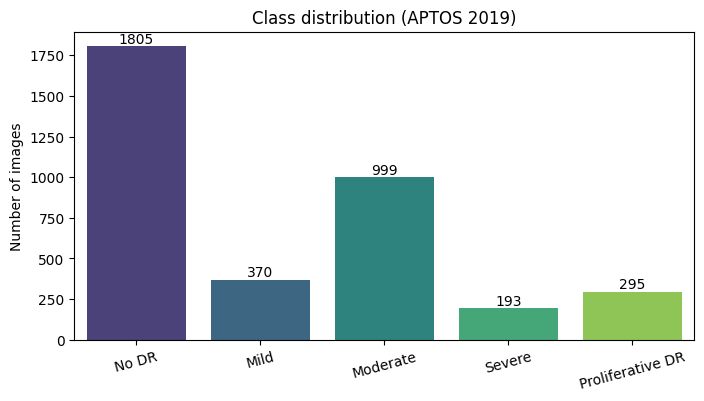

In [3]:
# ---------- Class distribution ----------
counts = df["diagnosis"].value_counts().sort_index()
dist = pd.DataFrame({"stage": CLASS_NAMES, "count": counts.values,
                     "percent": (counts.values / counts.sum() * 100).round(1)})
display(dist)
print(f"Imbalance ratio (largest / smallest class): {counts.max() / counts.min():.1f} : 1")

plt.figure(figsize=(8, 4))
ax = sns.barplot(x=CLASS_NAMES, y=counts.values, palette="viridis")
for p, c in zip(ax.patches, counts.values):
    ax.annotate(str(c), (p.get_x() + p.get_width() / 2, p.get_height()), ha="center", va="bottom")
plt.title("Class distribution (APTOS 2019)"); plt.ylabel("Number of images"); plt.xticks(rotation=15)
save_fig("01_class_distribution.png"); plt.show()

Width  range: 474 - 4288 px
Height range: 358 - 2848 px
Distinct resolutions in sample: 15
Saved figure -> /kaggle/working/figures/02_resolutions.png


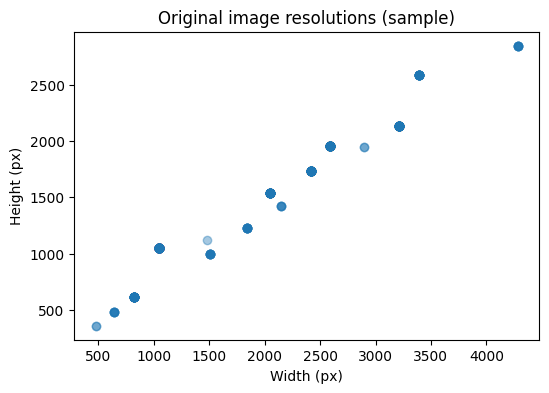

In [4]:
# ---------- Image resolution statistics (PIL reads only the header, so this is fast) ----------
sizes = np.array([Image.open(p).size for p in df["path"].sample(min(400, len(df)), random_state=SEED)])
print(f"Width  range: {sizes[:,0].min()} - {sizes[:,0].max()} px")
print(f"Height range: {sizes[:,1].min()} - {sizes[:,1].max()} px")
print("Distinct resolutions in sample:", len({tuple(s) for s in sizes}))

plt.figure(figsize=(6, 4))
plt.scatter(sizes[:, 0], sizes[:, 1], alpha=0.4)
plt.xlabel("Width (px)"); plt.ylabel("Height (px)"); plt.title("Original image resolutions (sample)")
save_fig("02_resolutions.png"); plt.show()

Saved figure -> /kaggle/working/figures/03_raw_samples.png


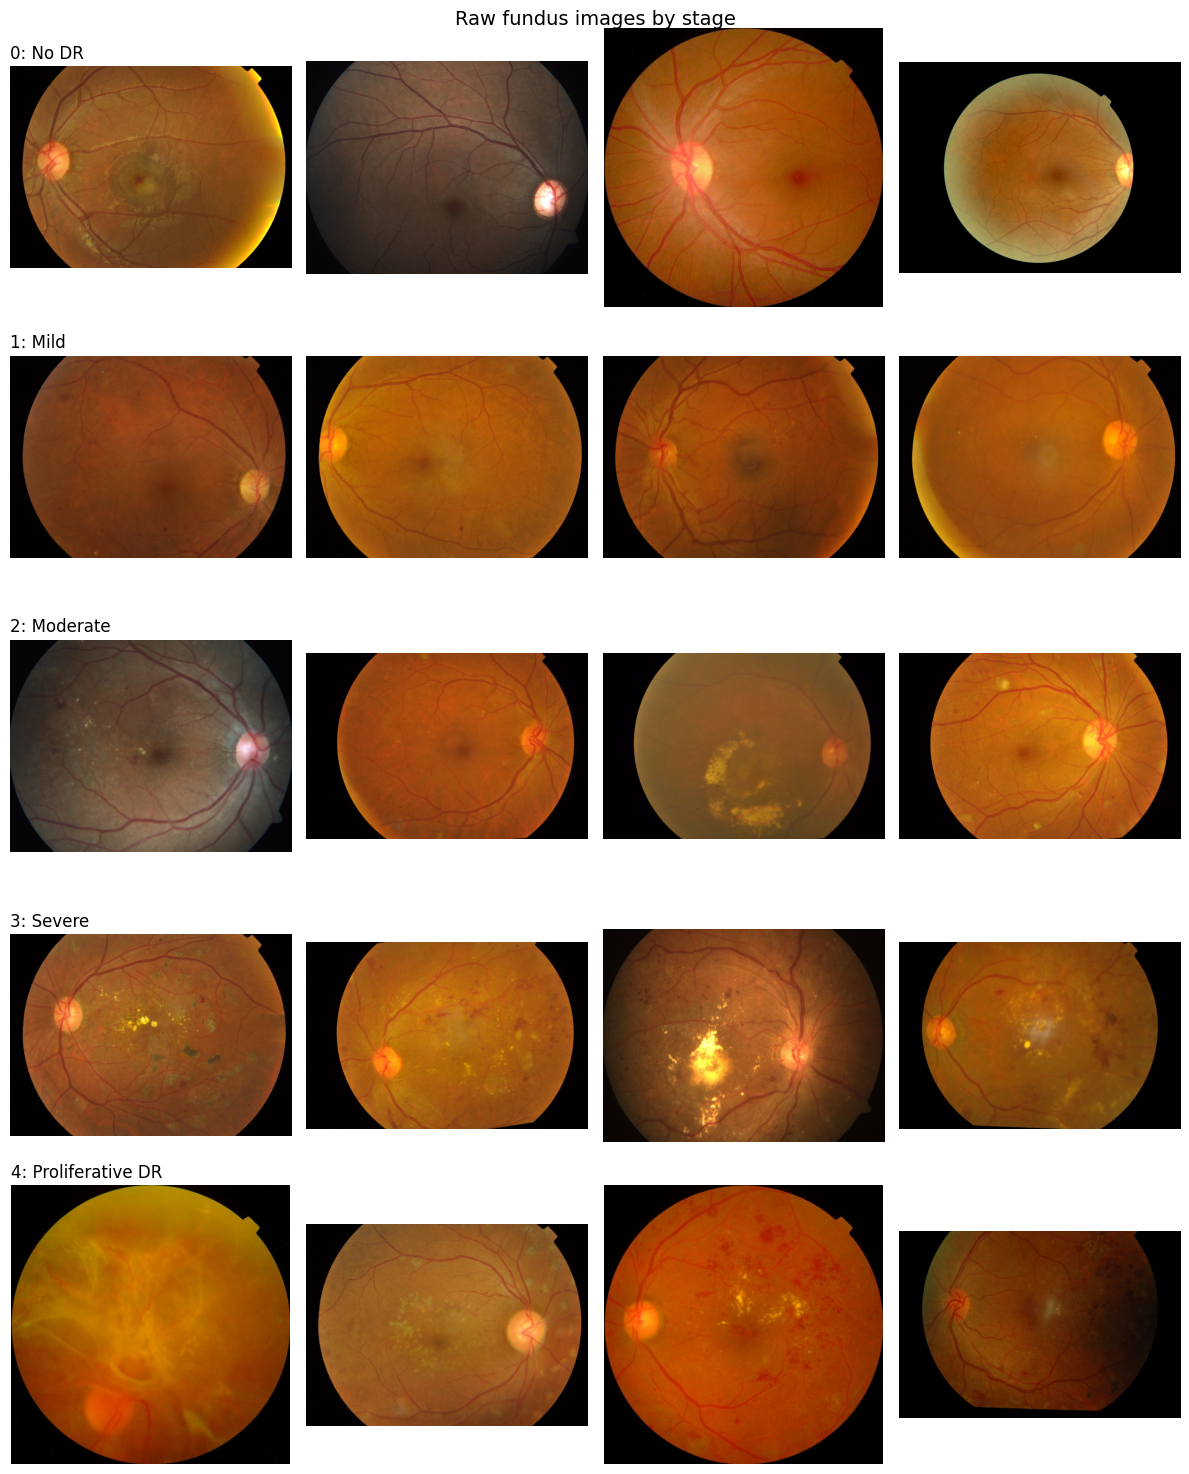

In [5]:
# ---------- Sample raw images per class ----------
def read_rgb(path):
    img = cv2.imread(path)                       # OpenCV loads BGR
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(NUM_CLASSES, 4, figsize=(12, 15))
for c in range(NUM_CLASSES):
    paths = df[df["diagnosis"] == c]["path"].sample(4, random_state=SEED, replace=True).values
    for j, p in enumerate(paths):
        axes[c, j].imshow(read_rgb(p)); axes[c, j].axis("off")
        if j == 0: axes[c, j].set_title(f"{c}: {CLASS_NAMES[c]}", loc="left", fontsize=12)
plt.suptitle("Raw fundus images by stage", fontsize=14); plt.tight_layout()
save_fig("03_raw_samples.png"); plt.show()

## 3. Image preprocessing
Raw images vary in resolution, black border size, brightness and camera. The pipeline:

1. **Crop black borders** — remove the uninformative dark frame around the retina.
2. **Pad to square + resize to 300×300** — keeps the retina round and matches the CNN input (`INTER_AREA` for clean downscaling).
3. **Noise removal** — 3×3 median filter removes salt-and-pepper sensor noise while keeping edges.
4. **Contrast enhancement (CLAHE)** — Contrast Limited Adaptive Histogram Equalisation on the L channel of LAB colour space; boosts local contrast of microaneurysms and exudates without shifting colours.
5. **Edge enhancement (unsharp masking)** — `1.5·img − 0.5·blur` sharpens vessel and lesion boundaries.
6. **Circular mask** — sets everything outside the retina to black, removing edge artefacts.

An alternative, **Ben Graham's local-average subtraction** (`4·img − 4·GaussianBlur + 128`, used by the Kaggle competition winner), is also implemented and compared with full training in Experiment 3.

Loading and resizing (the slow part) happens **once**; the enhancement steps run on the cached 300×300 images.

In [6]:
def crop_black_borders(img, tol=7):
    # Keep only rows/columns that contain pixels brighter than `tol`
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    mask = gray > tol
    if mask.sum() == 0:
        return img
    rows, cols = np.where(mask.any(1))[0], np.where(mask.any(0))[0]
    return img[rows[0]:rows[-1] + 1, cols[0]:cols[-1] + 1]

def pad_to_square(img):
    # Pad with black so the retina stays circular after resizing
    h, w = img.shape[:2]; s = max(h, w)
    top, left = (s - h) // 2, (s - w) // 2
    return cv2.copyMakeBorder(img, top, s - h - top, left, s - w - left, cv2.BORDER_CONSTANT, value=0)

def load_and_resize(path, size=IMG_SIZE):
    # Stage A (slow, done once): read -> crop borders -> square -> resize
    img = read_rgb(path)
    img = pad_to_square(crop_black_borders(img))
    return cv2.resize(img, (size, size), interpolation=cv2.INTER_AREA)

def denoise(img):
    return cv2.medianBlur(img, 3)

def apply_clahe(img, clip=2.0, grid=8):
    # CLAHE on lightness only, so colour information (e.g. red haemorrhages) is preserved
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    l = cv2.createCLAHE(clipLimit=clip, tileGridSize=(grid, grid)).apply(l)
    return cv2.cvtColor(cv2.merge([l, a, b]), cv2.COLOR_LAB2RGB)

def unsharp_mask(img, sigma=2.0, amount=0.5):
    # Edge enhancement: add back the high-frequency detail (img - blur)
    blur = cv2.GaussianBlur(img, (0, 0), sigma)
    return cv2.addWeighted(img, 1 + amount, blur, -amount, 0)

def ben_graham(img, sigma=None):
    # Subtract local average colour -> highlights lesions, normalises lighting
    sigma = sigma or img.shape[0] / 30
    return cv2.addWeighted(img, 4, cv2.GaussianBlur(img, (0, 0), sigma), -4, 128)

def circular_mask(img, scale=0.96):
    h, w = img.shape[:2]
    mask = np.zeros((h, w), np.uint8)
    cv2.circle(mask, (w // 2, h // 2), int(min(h, w) / 2 * scale), 1, -1)
    return img * mask[..., None]

def enhance(img, mode="clahe_unsharp"):
    # Stage B (fast): enhancement on a cached IMG_SIZE x IMG_SIZE image
    if mode == "raw":
        return img
    img = denoise(img)
    if mode == "clahe_unsharp":
        img = unsharp_mask(apply_clahe(img))
    elif mode == "ben_graham":
        img = ben_graham(img)
    else:
        raise ValueError(mode)
    return circular_mask(img)

def preprocess_fundus(path, mode="clahe_unsharp"):
    # Full pipeline for a single image (used for inference and in the app)
    return enhance(load_and_resize(path), mode)

Saved figure -> /kaggle/working/figures/04_preprocessing_steps.png


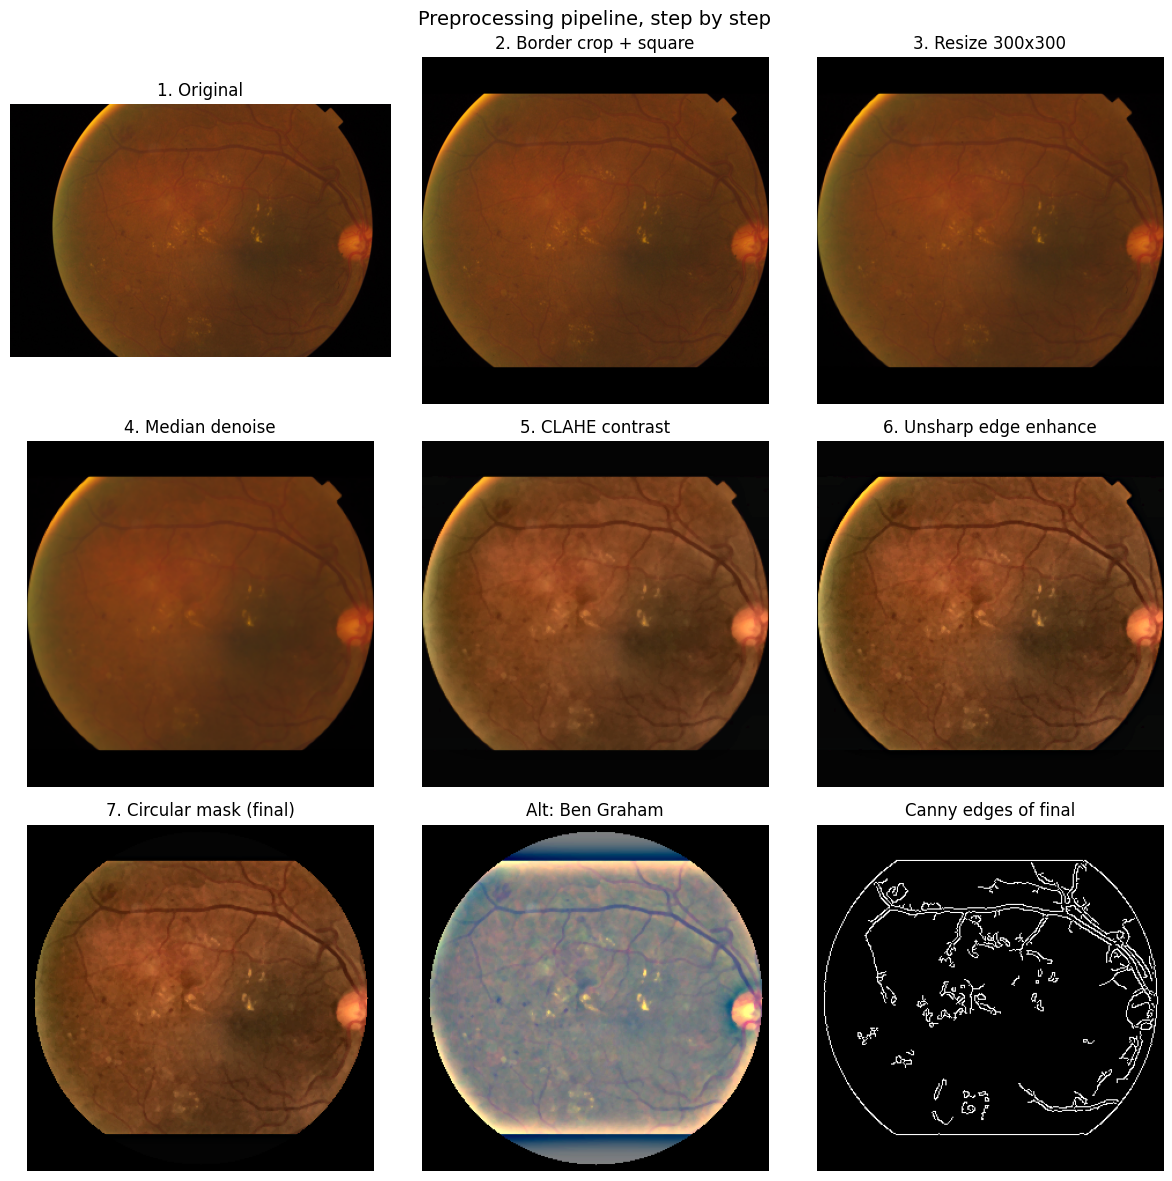

In [7]:
# ---------- Visual evidence: every preprocessing step on one image ----------
sample_path = df[df["diagnosis"] == 2]["path"].iloc[0]
orig = read_rgb(sample_path)
s1 = pad_to_square(crop_black_borders(orig))
s2 = cv2.resize(s1, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)
s3 = denoise(s2)
s4 = apply_clahe(s3)
s5 = unsharp_mask(s4)
s6 = circular_mask(s5)
bg = circular_mask(ben_graham(s3))
edges = cv2.Canny(cv2.cvtColor(s6, cv2.COLOR_RGB2GRAY), 40, 120)   # edge map for illustration

steps = [(orig, "1. Original"), (s1, "2. Border crop + square"), (s2, f"3. Resize {IMG_SIZE}x{IMG_SIZE}"),
         (s3, "4. Median denoise"), (s4, "5. CLAHE contrast"), (s5, "6. Unsharp edge enhance"),
         (s6, "7. Circular mask (final)"), (bg, "Alt: Ben Graham"), (edges, "Canny edges of final")]
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
for ax, (im, t) in zip(axes.ravel(), steps):
    ax.imshow(im, cmap="gray" if im.ndim == 2 else None); ax.set_title(t); ax.axis("off")
plt.suptitle("Preprocessing pipeline, step by step", fontsize=14); plt.tight_layout()
save_fig("04_preprocessing_steps.png"); plt.show()

In [8]:
# ---------- Quantitative evidence: contrast and sharpness before vs after ----------
def contrast_rms(img):  return cv2.cvtColor(img, cv2.COLOR_RGB2GRAY).std()
def sharpness(img):     return cv2.Laplacian(cv2.cvtColor(img, cv2.COLOR_RGB2GRAY), cv2.CV_64F).var()

rows = []
for p in df["path"].sample(min(100, len(df)), random_state=SEED):
    base = load_and_resize(p)
    for mode in ["raw", "clahe_unsharp", "ben_graham"]:
        im = enhance(base, mode)
        rows.append({"mode": mode, "RMS contrast": contrast_rms(im), "Laplacian sharpness": sharpness(im)})
quality = pd.DataFrame(rows).groupby("mode").mean().round(2)
display(quality)

,RMS contrast,Laplacian sharpness
mode,,
ben_graham,65.97,1566.59
clahe_unsharp,49.71,441.72
raw,41.75,101.60


Saved figure -> /kaggle/working/figures/05_clahe_histogram.png


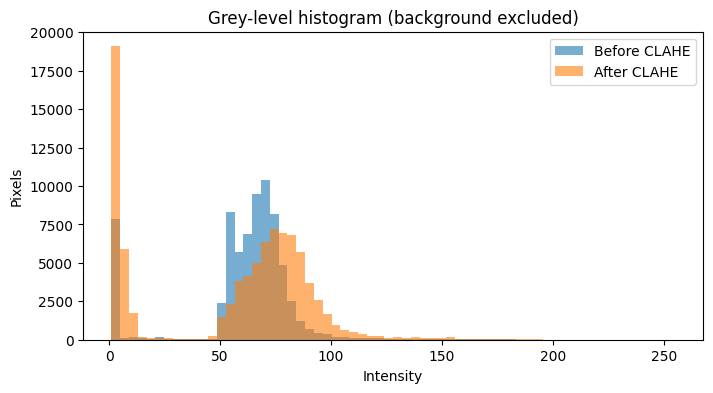

In [9]:
# ---------- Histogram of intensities before vs after CLAHE ----------
plt.figure(figsize=(8, 4))
plt.hist(cv2.cvtColor(s3, cv2.COLOR_RGB2GRAY).ravel(), bins=64, range=(1, 255), alpha=0.6, label="Before CLAHE")
plt.hist(cv2.cvtColor(s4, cv2.COLOR_RGB2GRAY).ravel(), bins=64, range=(1, 255), alpha=0.6, label="After CLAHE")
plt.legend(); plt.title("Grey-level histogram (background excluded)"); plt.xlabel("Intensity"); plt.ylabel("Pixels")
save_fig("05_clahe_histogram.png"); plt.show()

In [10]:
# ---------- Stage A for the whole dataset (parallel, once) ----------
t0 = time.time()
X_base = np.stack(Parallel(n_jobs=-1)(delayed(load_and_resize)(p) for p in df["path"]))
y_all = df["diagnosis"].values.astype(int)
print(f"Loaded {X_base.shape} in {time.time() - t0:.0f}s  ({X_base.nbytes / 1e6:.0f} MB)")

def build_set(mode):
    # Stage B for the whole dataset for a given enhancement mode
    return np.stack([enhance(im, mode) for im in X_base])

Loaded (3662, 300, 300, 3) in 210s  (989 MB)


## 4. Stratified train / validation / test split
70 % train, 15 % validation, 15 % test, stratified so every split keeps the class ratio. The split is made on image indices **before** any augmentation or oversampling, so no augmented copy of a test image can leak into training.

,train,val,test
No DR,1263,271,271
Mild,259,55,56
Moderate,699,150,150
Severe,135,29,29
Proliferative DR,207,44,44
Total,2563,549,550


Saved figure -> /kaggle/working/figures/06_split_distribution.png


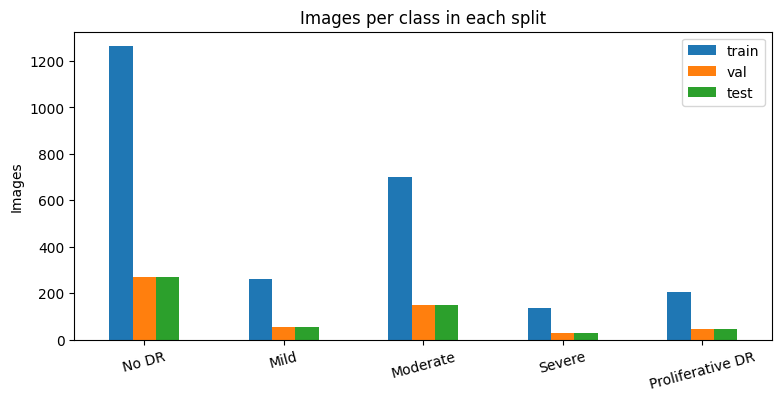

In [11]:
idx = np.arange(len(df))
train_idx, temp_idx = train_test_split(idx, test_size=0.30, stratify=y_all, random_state=SEED)
val_idx, test_idx   = train_test_split(temp_idx, test_size=0.50, stratify=y_all[temp_idx], random_state=SEED)

split_table = pd.DataFrame({name: np.bincount(y_all[ix], minlength=NUM_CLASSES)
                            for name, ix in [("train", train_idx), ("val", val_idx), ("test", test_idx)]},
                           index=CLASS_NAMES)
split_table.loc["Total"] = split_table.sum()
display(split_table)

split_table.drop("Total").plot(kind="bar", figsize=(9, 4))
plt.title("Images per class in each split"); plt.ylabel("Images"); plt.xticks(rotation=15)
save_fig("06_split_distribution.png"); plt.show()

## 5. Data augmentation and class balancing
**Augmentation** (training set only, applied on the fly so every epoch sees new variants):
- Random horizontal + vertical flips and 360° rotation — a retina has no fixed orientation, so this is label-preserving.
- Random zoom (±15 %) and small translations — simulate different camera framing.
- Random brightness and contrast (±15 %) — simulate different cameras and lighting.

Geometric transforms fill with black, matching the fundus background.

**Class balancing:** the dataset is heavily imbalanced (No DR ≈ 49 %, Severe ≈ 5 %). Three strategies are implemented and compared with full training in Experiment 4:
- `sqrt` — class weights `sqrt(n_samples / (n_classes · n_class))`: a milder correction that protects overall accuracy
- `balanced` — class weights `n_samples / (n_classes · n_class)`: errors on rare stages cost as much as on common ones
- `oversample` — minority images repeated until every class matches the largest (each repeat is augmented differently)

**Data pipeline:** images stay in one NumPy array; `tf.data` streams batches of *indices* and gathers the pixels, so memory use stays flat whatever the balancing method.

                  balanced  sqrt
No DR                 0.41  0.50
Mild                  1.98  1.10
Moderate              0.73  0.67
Severe                3.80  1.52
Proliferative DR      2.48  1.23


I0000 00:00:1790711668.839469      22 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1790711668.845502      22 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


,no balancing,sqrt weights,balanced weights,oversample
No DR,1263,626.0,513.0,1263
Mild,259,284.0,513.0,1263
Moderate,699,466.0,513.0,1263
Severe,135,205.0,513.0,1263
Proliferative DR,207,254.0,513.0,1263


Saved figure -> /kaggle/working/figures/07_class_balancing.png


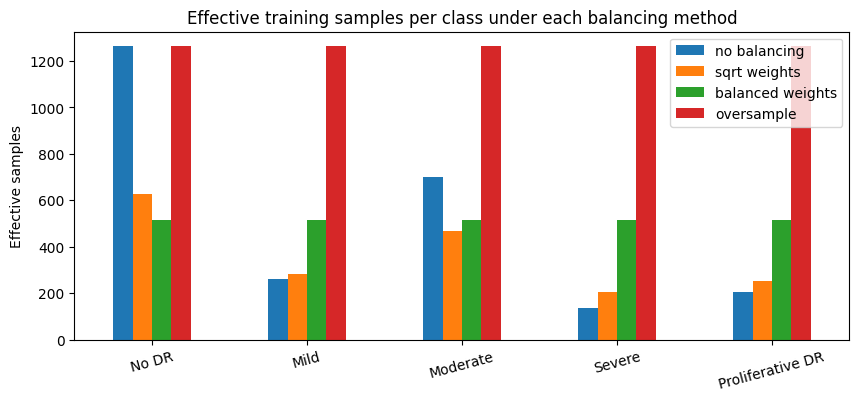

In [12]:
augmenter = keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.5, fill_mode="constant"),                 # up to ±180°
    layers.RandomZoom((-0.15, 0.15), fill_mode="constant"),
    layers.RandomTranslation(0.05, 0.05, fill_mode="constant"),
    layers.RandomBrightness(0.15, value_range=(0, 255)),
    layers.RandomContrast(0.15),
], name="augmentation")

# ---------- Class weights ----------
cw = compute_class_weight("balanced", classes=np.arange(NUM_CLASSES), y=y_all[train_idx])
WEIGHT_SETS = {"balanced": cw, "sqrt": np.sqrt(cw) / np.sqrt(cw).mean()}
print(pd.DataFrame(WEIGHT_SETS, index=CLASS_NAMES).round(2))

def oversample(indices, labels):
    # Repeat minority-class indices until every class matches the largest class
    counts = np.bincount(labels[indices], minlength=NUM_CLASSES)
    rng = np.random.default_rng(SEED); out = []
    for c in range(NUM_CLASSES):
        ci = indices[labels[indices] == c]
        out.append(np.concatenate([ci, rng.choice(ci, counts.max() - len(ci), replace=True)]))
    return rng.permutation(np.concatenate(out))

Y_ONEHOT = keras.utils.to_categorical(y_all, NUM_CLASSES).astype("float32")

def make_dataset(X, idx, training, balance=None, flip=None):
    # tf.data pipeline over image INDICES: (image, one-hot label[, sample weight]) batches
    # balance: sqrt / balanced / oversample (training only; anything else = no balancing); flip: None / "lr" / "ud" / "both" (TTA)
    balance = balance or BALANCE_METHOD
    idx = np.asarray(idx)
    if training and balance == "oversample":
        idx = oversample(idx, y_all)
    use_w = training and balance in WEIGHT_SETS
    w_all = WEIGHT_SETS[balance][y_all].astype("float32") if use_w else None

    def gather(ib):
        ib = ib.astype(np.int64)
        out = [X[ib].astype(np.float32), Y_ONEHOT[ib]]
        if use_w: out.append(w_all[ib])
        return tuple(out)

    ds = tf.data.Dataset.from_tensor_slices(idx)
    if training:
        ds = ds.shuffle(len(idx), seed=SEED, reshuffle_each_iteration=True)
    S = X.shape[1]                                   # image size of this array (300 or 380)
    ds = ds.batch(BATCH_SIZE if S <= IMG_SIZE else BATCH_SIZE_HIRES)
    types = [tf.float32, tf.float32] + ([tf.float32] if use_w else [])
    def load(ib):
        out = tf.numpy_function(gather, [ib], types)
        out[0].set_shape([None, S, S, 3]); out[1].set_shape([None, NUM_CLASSES])
        if use_w: out[2].set_shape([None])
        return tuple(out)
    ds = ds.map(load, num_parallel_calls=tf.data.AUTOTUNE)
    if training:   # augmentation runs on whole batches (each image gets its own random transform)
        ds = ds.map(lambda img, *rest: (tf.clip_by_value(augmenter(img, training=True), 0, 255), *rest),
                    num_parallel_calls=tf.data.AUTOTUNE)
    if flip in ("lr", "both"): ds = ds.map(lambda img, *rest: (tf.reverse(img, [2]), *rest))
    if flip in ("ud", "both"): ds = ds.map(lambda img, *rest: (tf.reverse(img, [1]), *rest))
    return ds.prefetch(tf.data.AUTOTUNE)

# Class distribution the model effectively "sees" under each balancing method
raw_counts = np.bincount(y_all[train_idx], minlength=NUM_CLASSES)
eff = pd.DataFrame({"no balancing": raw_counts,
                    "sqrt weights": raw_counts * WEIGHT_SETS["sqrt"],
                    "balanced weights": raw_counts * WEIGHT_SETS["balanced"],
                    "oversample": np.bincount(y_all[oversample(train_idx, y_all)], minlength=NUM_CLASSES)},
                   index=CLASS_NAMES).round()
display(eff)
eff.plot(kind="bar", figsize=(10, 4))
plt.title("Effective training samples per class under each balancing method"); plt.ylabel("Effective samples")
plt.xticks(rotation=15)
save_fig("07_class_balancing.png"); plt.show()

Saved figure -> /kaggle/working/figures/08_augmentation_examples.png


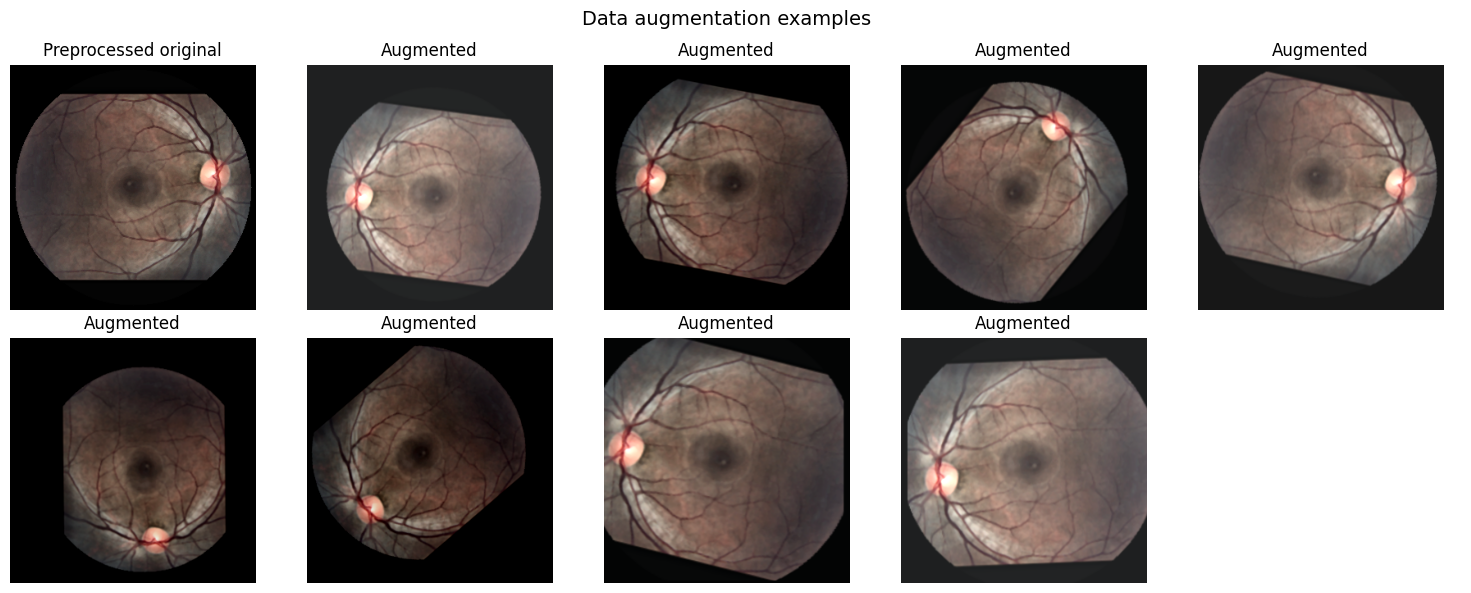

In [13]:
# ---------- Visual evidence: 8 augmentations of one preprocessed image ----------
demo = enhance(X_base[train_idx[0]], "clahe_unsharp").astype("float32")
fig, axes = plt.subplots(2, 5, figsize=(15, 6))  # last panel left blank
axes[0, 0].imshow(demo.astype("uint8")); axes[0, 0].set_title("Preprocessed original")
for ax in axes.ravel()[1:9]:
    aug = tf.clip_by_value(augmenter(demo[None], training=True)[0], 0, 255).numpy().astype("uint8")
    ax.imshow(aug); ax.set_title("Augmented")
for ax in axes.ravel(): ax.axis("off")
plt.suptitle("Data augmentation examples", fontsize=14); plt.tight_layout()
save_fig("08_augmentation_examples.png"); plt.show()

## 6. Model builder, training loop and validation-QWK callback
Every model = **ImageNet-pretrained backbone** (no top) → Global Average Pooling → Dropout → Dense(256, ReLU, L2) → Dropout → Dense(5, softmax).

- EfficientNetB0/B3 include their own input scaling, so they take raw 0–255 pixels.
- ResNet50V2 and MobileNetV2 expect pixels in [−1, 1], so a `Rescaling` layer is added.
- The backbone is called with `training=False`, so its BatchNorm statistics stay fixed even after unfreezing (the recommended Keras fine-tuning practice for small datasets).
- Loss: categorical cross-entropy with label smoothing 0.05 (reduces over-confidence; neighbouring stages are visually similar).
- **Validation QWK callback:** after every epoch the model is scored on the validation set with quadratic weighted kappa; early stopping and checkpointing keep the epoch with the best QWK (not just the lowest loss).
- `train_full()` runs the complete two-phase schedule, so Experiments 3–4 and the final model use exactly the same procedure.

In [14]:
# name -> (Keras constructor, needs [-1, 1] input rescaling?)
BACKBONES = {
    "EfficientNetB0": (keras.applications.EfficientNetB0, False),
    "EfficientNetB3": (keras.applications.EfficientNetB3, False),
    "EfficientNetB4": (keras.applications.EfficientNetB4, False),
    "ResNet50V2":     (keras.applications.ResNet50V2,     True),
    "MobileNetV2":    (keras.applications.MobileNetV2,    True),
}

def build_model(backbone="EfficientNetB0", dropout=0.3, dense_units=256, lr=1e-3, img_size=None):
    img_size = img_size or IMG_SIZE
    ctor, rescale = BACKBONES[backbone]
    inputs = keras.Input((img_size, img_size, 3), name="image")
    x = layers.Rescaling(1 / 127.5, offset=-1, name="rescale")(inputs) if rescale else inputs
    base = ctor(include_top=False, weights=WEIGHTS, input_shape=(img_size, img_size, 3))
    base.trainable = False                                   # phase 1: frozen feature extractor
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D(name="gap")(x)
    x = layers.Dropout(dropout, name="drop1")(x)
    x = layers.Dense(dense_units, activation="relu", kernel_regularizer=regularizers.l2(1e-4), name="fc")(x)
    x = layers.Dropout(dropout, name="drop2")(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax", name="stage")(x)
    model = keras.Model(inputs, outputs, name=f"DR_{backbone}")
    compile_model(model, lr)
    return model, base

def compile_model(model, lr):
    model.compile(optimizer=keras.optimizers.Adam(lr),
                  loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
                  metrics=["accuracy"])

def metrics(true, pred):
    return {"accuracy": accuracy_score(true, pred),
            "macro_f1": f1_score(true, pred, average="macro"),
            "qwk": cohen_kappa_score(true, pred, weights="quadratic")}

def predict_probs(model, X, idx, tta=False):
    # Class probabilities; with TTA, average over original + 3 flipped views
    views = [None, "lr", "ud", "both"] if tta else [None]
    return np.mean([model.predict(make_dataset(X, idx, False, flip=f), verbose=0) for f in views], axis=0)

def evaluate_split(model, X, idx, tta=False):
    # Returns probabilities and headline metrics on a split
    probs = predict_probs(model, X, idx, tta)
    return probs, metrics(y_all[idx], probs.argmax(1))

class ValQWK(keras.callbacks.Callback):
    # Adds val_qwk / val_macro_f1 to the logs after each epoch
    def __init__(self, X):
        super().__init__(); self.X = X
    def on_epoch_end(self, epoch, logs=None):
        probs = self.model.predict(make_dataset(self.X, val_idx, False), verbose=0)
        m = metrics(y_all[val_idx], probs.argmax(1))
        logs["val_qwk"], logs["val_macro_f1"] = m["qwk"], m["macro_f1"]
        print(f" - val_qwk: {m['qwk']:.4f} - val_macro_f1: {m['macro_f1']:.4f}")

def unfreeze(base, fraction):
    # Unfreeze the top `fraction` of backbone layers; BatchNorm layers stay frozen
    base.trainable = True
    n_freeze = int(len(base.layers) * (1 - fraction))
    for i, layer in enumerate(base.layers):
        layer.trainable = i >= n_freeze and not isinstance(layer, layers.BatchNormalization)
    return sum(l.trainable for l in base.layers)

def train_full(X, backbone, lr, dropout, balance, head_epochs, fine_epochs, tag=None, verbose=0, seed=SEED):
    # Complete two-phase transfer-learning run. Returns (model, base, history_phase1, history_phase2)
    set_seed(seed); keras.backend.clear_session()
    model, base = build_model(backbone, dropout=dropout, lr=lr, img_size=X.shape[1])
    train_ds = make_dataset(X, train_idx, True, balance=balance)
    val_ds = make_dataset(X, val_idx, False)
    def cbs(phase, patience):
        c = [ValQWK(X),
             keras.callbacks.EarlyStopping(monitor="val_qwk", mode="max", patience=patience,
                                           restore_best_weights=True, verbose=verbose),
             keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=2, min_lr=1e-7, verbose=verbose)]
        if tag:   # final run: keep a checkpoint and a CSV log for the report
            c += [keras.callbacks.ModelCheckpoint(os.path.join(OUT_DIR, f"{tag}_best.keras"), monitor="val_qwk",
                                                  mode="max", save_best_only=True),
                  keras.callbacks.CSVLogger(os.path.join(OUT_DIR, f"training_log_{phase}.csv"))]
        return c
    h1 = model.fit(train_ds, validation_data=val_ds, epochs=head_epochs, callbacks=cbs("phase1", 3), verbose=verbose)
    n = unfreeze(base, FINE_TUNE_FRACTION)
    if verbose: print(f"Phase 2: {n} / {len(base.layers)} backbone layers trainable")
    compile_model(model, FINE_TUNE_LR)          # re-compile is required after changing trainable flags
    h2 = model.fit(train_ds, validation_data=val_ds, epochs=fine_epochs, callbacks=cbs("phase2", 6), verbose=verbose)
    return model, base, h1, h2

def quick_train(X, backbone="EfficientNetB0", lr=1e-3, dropout=0.3, epochs=EPOCHS_SEARCH):
    # Short frozen-backbone run used for Experiments 1-2 (same seed -> fair comparison)
    set_seed(); keras.backend.clear_session()
    model, _ = build_model(backbone, dropout=dropout, lr=lr)
    t0 = time.time()
    model.fit(make_dataset(X, train_idx, True), validation_data=make_dataset(X, val_idx, False),
              epochs=epochs, verbose=0)
    _, m = evaluate_split(model, X, val_idx)
    m.update(train_time_s=round(time.time() - t0), params_M=round(model.count_params() / 1e6, 2))
    return m

### Re-using a previously trained model (optional)
If `REUSE_TRAINED_MODEL = True` and the output of an earlier run is attached as an input, the settings that run selected are loaded from its `results.json`, the four experiments are skipped (their tables and figures stay in that earlier version), and the saved model is loaded instead of retrained. The data split is identical because every seed is fixed.

In [15]:
PREV_DIR = None
if REUSE_TRAINED_MODEL:
    root = os.environ.get("DR_DATA_ROOT", "/kaggle/input")
    hits = [h for h in glob.glob(os.path.join(root, "**", "dr_model.keras"), recursive=True)
            if os.path.exists(os.path.join(os.path.dirname(h), "results.json"))]
    if hits:
        PREV_DIR = os.path.dirname(hits[0])
        sel = json.load(open(os.path.join(PREV_DIR, "results.json")))["selected"]
        BEST_BACKBONE, PREPROCESS_MODE, BALANCE_METHOD = sel["backbone"], sel["preprocess"], sel["balancing"]
        BEST_LR, BEST_DROPOUT = sel["lr"], sel["dropout"]
        RUN_BACKBONE_COMP = RUN_HP_SEARCH = RUN_PREPROC_EXP = RUN_BALANCE_EXP = False
print("Re-using trained model from:", PREV_DIR or "none (full training will run)")
print(f"Settings: {BEST_BACKBONE} | preprocessing={PREPROCESS_MODE} | balancing={BALANCE_METHOD} "
      f"| lr={BEST_LR} | dropout={BEST_DROPOUT}")

Re-using trained model from: /kaggle/input/notebooks/malindichathumini/dr-stage-detection-ensemble-v3
Settings: EfficientNetB0 | preprocessing=raw | balancing=oversample | lr=0.001 | dropout=0.4


## 7. Experiment 1 — CNN backbone comparison
Four ImageNet architectures (EfficientNetB0, EfficientNetB3, ResNet50V2, MobileNetV2), trained identically with frozen weights on unenhanced images (a neutral baseline). Selection criterion: validation **quadratic weighted kappa (QWK)**, the official APTOS metric, which penalises predictions further from the true stage more heavily. The test set is never used for any decision.

In [16]:
X_raw = build_set("raw")
if RUN_BACKBONE_COMP:
    comp = {}
    for name in BACKBONES:
        comp[name] = quick_train(X_raw, backbone=name); gc.collect()
        print(name, comp[name], "| RAM GB:", ram_gb())
    comp_df = pd.DataFrame(comp).T.round(4)
    display(comp_df)
    BEST_BACKBONE = comp_df[SELECT_METRIC].idxmax()
    comp_df[["accuracy", "macro_f1", "qwk"]].plot(kind="bar", figsize=(9, 4), rot=0)
    plt.title("Experiment 1: backbone comparison (validation set, frozen backbone)"); plt.ylim(0, 1)
    save_fig("09_backbone_comparison.png"); plt.show()
print("Selected backbone:", BEST_BACKBONE)

Selected backbone: EfficientNetB0


## 8. Experiment 2 — Hyperparameter tuning
Grid search over the head learning rate and dropout rate for the selected backbone.

In [17]:
if RUN_HP_SEARCH:
    grid = [(lr, d) for lr in [1e-3, 3e-4] for d in [0.2, 0.4]]
    hp_rows = []
    for lr, d in grid:
        m = quick_train(X_raw, backbone=BEST_BACKBONE, lr=lr, dropout=d)
        hp_rows.append({"learning_rate": lr, "dropout": d, **m}); gc.collect()
        print(hp_rows[-1], "| RAM GB:", ram_gb())
    hp_df = pd.DataFrame(hp_rows).round(4)
    display(hp_df)
    best = hp_df.loc[hp_df[SELECT_METRIC].idxmax()]
    BEST_LR, BEST_DROPOUT = float(best["learning_rate"]), float(best["dropout"])
    pivot = hp_df.pivot(index="dropout", columns="learning_rate", values=SELECT_METRIC)
    plt.figure(figsize=(5, 4)); sns.heatmap(pivot, annot=True, fmt=".3f", cmap="Blues")
    plt.title(f"Experiment 2: validation {SELECT_METRIC.upper()} (learning rate x dropout)")
    save_fig("10_hyperparameter_grid.png"); plt.show()
print(f"Selected: lr={BEST_LR}, dropout={BEST_DROPOUT}")

Selected: lr=0.001, dropout=0.4


## 9. Experiment 3 — Preprocessing comparison (full two-phase training)
Version 1 compared preprocessing with only 5 frozen epochs, which is too short to be reliable. Here every variant gets the **complete** two-phase schedule (frozen head, then full fine-tuning, early stopping on validation QWK), so the comparison reflects the final model.

In [18]:
if RUN_PREPROC_EXP:
    pre_rows = {}
    for mode in ["clahe_unsharp", "ben_graham", "raw"]:          # on a tie, the first (enhanced) mode wins
        X_mode = X_raw if mode == "raw" else build_set(mode)
        t0 = time.time()
        m_, _, _, _ = train_full(X_mode, BEST_BACKBONE, BEST_LR, BEST_DROPOUT, BALANCE_METHOD,
                                 EPOCHS_COMPACT_HEAD, EPOCHS_COMPACT_FINE)
        _, pre_rows[mode] = evaluate_split(m_, X_mode, val_idx)
        pre_rows[mode]["train_time_min"] = round((time.time() - t0) / 60, 1)
        del m_, X_mode; gc.collect()
        print(mode, pre_rows[mode], "| RAM GB:", ram_gb())
    pre_df = pd.DataFrame(pre_rows).T.round(4)
    display(pre_df)
    PREPROCESS_MODE = pre_df[SELECT_METRIC].idxmax()
    pre_df[["accuracy", "macro_f1", "qwk"]].plot(kind="bar", figsize=(8, 4), rot=0)
    plt.title("Experiment 3: preprocessing with full training (validation set)"); plt.ylim(0, 1)
    save_fig("11_preprocessing_comparison.png"); plt.show()
print("Selected preprocessing:", PREPROCESS_MODE)
X_all = X_raw if PREPROCESS_MODE == "raw" else build_set(PREPROCESS_MODE)   # final preprocessed dataset

Selected preprocessing: raw


## 10. Experiment 4 — Class-balancing comparison (full two-phase training)
Same backbone, hyperparameters and preprocessing; only the imbalance strategy changes.

In [19]:
if RUN_BALANCE_EXP:
    bal_rows = {}
    for bal in ["balanced", "sqrt", "oversample"]:
        t0 = time.time()
        m_, _, _, _ = train_full(X_all, BEST_BACKBONE, BEST_LR, BEST_DROPOUT, bal,
                                 EPOCHS_COMPACT_HEAD, EPOCHS_COMPACT_FINE)
        _, bal_rows[bal] = evaluate_split(m_, X_all, val_idx)
        bal_rows[bal]["train_time_min"] = round((time.time() - t0) / 60, 1)
        del m_; gc.collect()
        print(bal, bal_rows[bal], "| RAM GB:", ram_gb())
    bal_df = pd.DataFrame(bal_rows).T.round(4)
    display(bal_df)
    BALANCE_METHOD = bal_df[SELECT_METRIC].idxmax()
    bal_df[["accuracy", "macro_f1", "qwk"]].plot(kind="bar", figsize=(8, 4), rot=0)
    plt.title("Experiment 4: class-balancing methods (validation set)"); plt.ylim(0, 1)
    save_fig("12_balancing_comparison.png"); plt.show()
print("Selected balancing:", BALANCE_METHOD)

Selected balancing: oversample


## 11. Final training — two-phase transfer learning
**Phase 1 (feature extraction):** backbone frozen, only the new head learns (higher learning rate).
**Phase 2 (fine-tuning):** the whole backbone is unfrozen (BatchNorm layers stay frozen) and trained with a very small learning rate, so the ImageNet features adapt to retinal lesions without being destroyed.

**Callbacks / overfitting control**
- `ValQWK` — scores the validation set after each epoch
- `EarlyStopping` on validation QWK (patience 3 / 6, restores best weights)
- `ReduceLROnPlateau` (×0.3 when val loss stalls for 2 epochs) — learning-rate scheduling
- `ModelCheckpoint` (keeps the best-QWK model on disk) and `CSVLogger` (training log for the report)
- plus Dropout, L2 weight decay, label smoothing and augmentation.

In [20]:
print(f"Final model: {BEST_BACKBONE} | preprocessing={PREPROCESS_MODE} | balancing={BALANCE_METHOD} "
      f"| lr={BEST_LR} | dropout={BEST_DROPOUT} | img={IMG_SIZE}px")
class LoggedHistory:
    # Minimal stand-in for a Keras History object, rebuilt from a CSVLogger file
    def __init__(self, csv_path):
        self.history = pd.read_csv(csv_path).to_dict(orient="list")

if PREV_DIR:
    model = keras.models.load_model(os.path.join(PREV_DIR, "dr_model.keras"))
    base = next(l for l in model.layers if isinstance(l, keras.Model))
    hist1 = LoggedHistory(os.path.join(PREV_DIR, "training_log_phase1.csv"))
    hist2 = LoggedHistory(os.path.join(PREV_DIR, "training_log_phase2.csv"))
    for f in ["training_log_phase1.csv", "training_log_phase2.csv"]:          # keep the logs with this run's outputs
        shutil.copy(os.path.join(PREV_DIR, f), os.path.join(OUT_DIR, f))
    print("Loaded trained model and its training logs from", PREV_DIR)
else:
    t0 = time.time()
    model, base, hist1, hist2 = train_full(X_all, BEST_BACKBONE, BEST_LR, BEST_DROPOUT, BALANCE_METHOD,
                                           EPOCHS_HEAD, EPOCHS_FINE, tag="dr_model", verbose=2)
    print(f"Total training time: {(time.time() - t0) / 60:.1f} min | RAM GB: {ram_gb()}")
model.summary(show_trainable=True)

Final model: EfficientNetB0 | preprocessing=raw | balancing=oversample | lr=0.001 | dropout=0.4 | img=300px


Loaded trained model and its training logs from /kaggle/input/notebooks/malindichathumini/dr-stage-detection-ensemble-v3


Model: "DR_EfficientNetB0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ image (InputLayer)          │ (None, 300, 300, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ efficientnetb0 (Functional) │ (None, 10, 10, 1280)  │  4,049,571 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ gap                         │ (None, 1280)          │          0 │   -   │
│ (GlobalAveragePooling2D)    │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ drop1 (Dropout)             │ (None, 1280)          │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ fc (Dense)                  │ (None, 256)           │    327,936 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ drop2 (Dropout)             │ (None, 256)           │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ stage (Dense)               │ (None, 5)             │      1,285 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 12,968,300 (49.47 MB)

 Trainable params: 4,294,753 (16.38 MB)

 Non-trainable params: 84,039 (328.28 KB)

 Optimizer params: 8,589,508 (32.77 MB)

Saved figure -> /kaggle/working/figures/13_accuracy_loss_qwk_curves.png


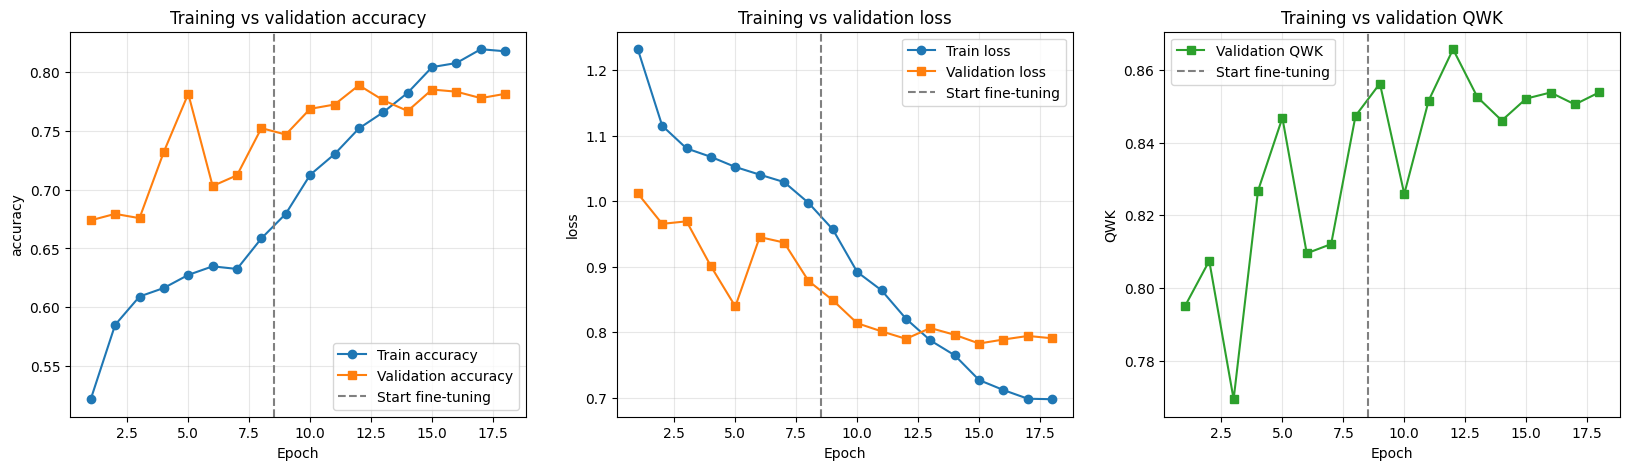

In [21]:
# ---------- Accuracy and loss curves (both phases) ----------
H = {k: hist1.history[k] + hist2.history[k] for k in ["accuracy", "val_accuracy", "loss", "val_loss", "val_qwk"]}
split = len(hist1.history["loss"])
epochs_axis = np.arange(1, len(H["loss"]) + 1)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for ax, metric in zip(axes[:2], ["accuracy", "loss"]):
    ax.plot(epochs_axis, H[metric], "o-", label=f"Train {metric}")
    ax.plot(epochs_axis, H[f"val_{metric}"], "s-", label=f"Validation {metric}")
axes[2].plot(epochs_axis, H["val_qwk"], "s-", color="tab:green", label="Validation QWK")
for ax, t in zip(axes, ["accuracy", "loss", "QWK"]):
    ax.axvline(split + 0.5, color="grey", ls="--", label="Start fine-tuning")
    ax.set_xlabel("Epoch"); ax.set_ylabel(t); ax.set_title(f"Training vs validation {t}")
    ax.legend(); ax.grid(alpha=0.3)
save_fig("13_accuracy_loss_qwk_curves.png"); plt.show()

## 12. Inference optimisation — TTA and stage thresholds
Two cheap improvements that need no retraining; both are decided on the **validation** set only:
1. **Test-time augmentation (TTA):** each image is predicted 4 times (original, horizontal flip, vertical flip, both) and the probabilities are averaged, which smooths out orientation-specific errors.
2. **Optimised stage thresholds:** DR stages are ordered, so each image gets an expected grade `E = Σ k·p(k)` (0–4). Four cut-points turn `E` into a stage; they are tuned by coordinate search to maximise validation QWK.

**Selection rule:** the option with the best *average* of accuracy, macro F1 and QWK on the validation set is used. QWK alone is not enough: in the first run of this notebook, thresholds tuned for QWK raised QWK but pushed borderline Mild cases into Moderate, cutting Mild recall and overall accuracy. A screening tool must also find the early (Mild) stage, so all three metrics count.

In [22]:
def expected_grade(probs):
    return probs @ np.arange(NUM_CLASSES)

def apply_thresholds(score, th):
    return np.digitize(score, th)

def optimise_thresholds(score, true, metric=SELECT_METRIC, passes=3):
    # Coordinate search: move one cut-point at a time to the value that maximises the metric
    th = np.array([0.5, 1.5, 2.5, 3.5])
    for _ in range(passes):
        for i in range(len(th)):
            lo = th[i - 1] + 0.01 if i > 0 else 0.0
            hi = th[i + 1] - 0.01 if i < len(th) - 1 else NUM_CLASSES - 1.0
            cands = np.linspace(lo, hi, 60)
            vals = [metrics(true, apply_thresholds(score, np.r_[th[:i], c, th[i + 1:]]))[metric] for c in cands]
            th[i] = cands[int(np.argmax(vals))]
    return th

val_true = y_all[val_idx]
val_plain = predict_probs(model, X_all, val_idx, tta=False)
val_tta   = predict_probs(model, X_all, val_idx, tta=True)
THRESHOLDS = optimise_thresholds(expected_grade(val_tta), val_true)

options = {
    "argmax":              (False, "argmax", metrics(val_true, val_plain.argmax(1))),
    "TTA + argmax":        (True,  "argmax", metrics(val_true, val_tta.argmax(1))),
    "TTA + thresholds":    (True,  "thresholds", metrics(val_true, apply_thresholds(expected_grade(val_tta), THRESHOLDS))),
}
opt_df = pd.DataFrame({k: v[2] for k, v in options.items()}).T.round(4)
opt_df["mean_score"] = opt_df[["accuracy", "macro_f1", "qwk"]].mean(axis=1).round(4)
print("Validation set:"); display(opt_df)
BEST_INFERENCE = opt_df["mean_score"].idxmax()
USE_TTA, DECISION = options[BEST_INFERENCE][0], options[BEST_INFERENCE][1]
print(f"Selected inference: {BEST_INFERENCE} | thresholds = {np.round(THRESHOLDS, 3).tolist()}")

def decide(probs):
    return apply_thresholds(expected_grade(probs), THRESHOLDS) if DECISION == "thresholds" else probs.argmax(1)

2026-09-29 19:54:59.490013: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-29 19:54:59.631797: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


2026-09-29 19:54:59.971175: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-29 19:55:00.113348: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


2026-09-29 19:55:00.934301: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-29 19:55:01.075899: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


I0000 00:00:1790711704.168149     100 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2026-09-29 19:55:14.154935: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-29 19:55:14.289495: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


2026-09-29 19:55:14.601494: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-29 19:55:14.742594: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


2026-09-29 19:55:15.582033: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-29 19:55:15.723158: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


Validation set:


,accuracy,macro_f1,qwk,mean_score
argmax,0.7887,0.6550,0.8657,0.7698
TTA + argmax,0.7832,0.6408,0.8478,0.7573
TTA + thresholds,0.7687,0.5562,0.8896,0.7382


Selected inference: argmax | thresholds = [0.994, 1.192, 2.587, 3.382]


## 12b. Version 4 — High-resolution ensemble
An ensemble averages the class probabilities of several independently trained models. Different models make different mistakes, so the average is usually more accurate and more stable than any single model.

**Members**
1. **EfficientNetB0, 300 px** (Version 2 model, loaded).
2. **EfficientNetB3, 300 px** (Version 3 member, loaded).
3. **EfficientNetB3, 380 px** (new): higher resolution keeps small lesions such as microaneurysms and tiny haemorrhages visible, which matters most for the Mild and Severe stages.
4. **EfficientNetB4, 380 px** (new): a deeper backbone whose native input size is 380 px.

The new members are trained with exactly the same two-phase schedule, preprocessing and balancing as the Version 2 model; only the backbone and the image size differ. The 380 px images are produced with the same crop, pad and resize steps.

**Selection (validation set only):** every non-empty combination of members, each with and without TTA, is scored with the same rule as section 12 (mean of accuracy, macro F1 and QWK). The Version 3 ensemble and the single model are among the candidates, so a new member is only used if it genuinely helps on validation. The test set is not used for this choice.

Loaded earlier member: B3 (seed 7) from /kaggle/input/notebooks/malindichathumini/dr-stage-detection-ensemble-v3/dr_model_member1.keras


High-resolution set (3662, 380, 380, 3) built in 186s | RAM GB: 8.1


       0/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step

 6037504/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

14737408/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

...

,accuracy,macro_f1,qwk
B0 (Version 2),0.7887,0.6550,0.8657
B3 (seed 7),0.7832,0.6469,0.8760
B3 380px (seed 11),0.8087,0.6494,0.8680
B4 380px (seed 13),0.7942,0.6710,0.8761


All combinations on the validation set (best first):


,members,tta,accuracy,macro_f1,qwk,mean_score
0,B0 (Version 2) + B3 380px (seed 11) + B4 380px...,False,0.8124,0.6815,0.8721,0.7886
1,B3 (seed 7) + B3 380px (seed 11),False,0.8069,0.6716,0.8817,0.7867
2,B0 (Version 2) + B3 (seed 7) + B3 380px (seed 11),True,0.8087,0.6713,0.8759,0.7853
3,B0 (Version 2) + B3 (seed 7) + B4 380px (seed 13),True,0.8015,0.6817,0.8727,0.7853
4,B0 (Version 2) + B4 380px (seed 13),True,0.8015,0.6791,0.8727,0.7844
5,B0 (Version 2) + B3 (seed 7) + B3 380px (seed ...,True,0.8051,0.6727,0.8751,0.7843
6,B3 380px (seed 11) + B4 380px (seed 13),False,0.8087,0.6684,0.8676,0.7816
7,B4 380px (seed 13),True,0.7960,0.6722,0.8743,0.7808
8,B4 380px (seed 13),False,0.7942,0.6710,0.8761,0.7804
9,B0 (Version 2) + B3 380px (seed 11) + B4 380px...,True,0.8015,0.6667,0.8728,0.7803


Best ensemble option (validation mean score 0.7886) vs single model option 'argmax' (0.7698) -> using ENSEMBLE


Saved figure -> /kaggle/working/figures/14b_ensemble_selection.png


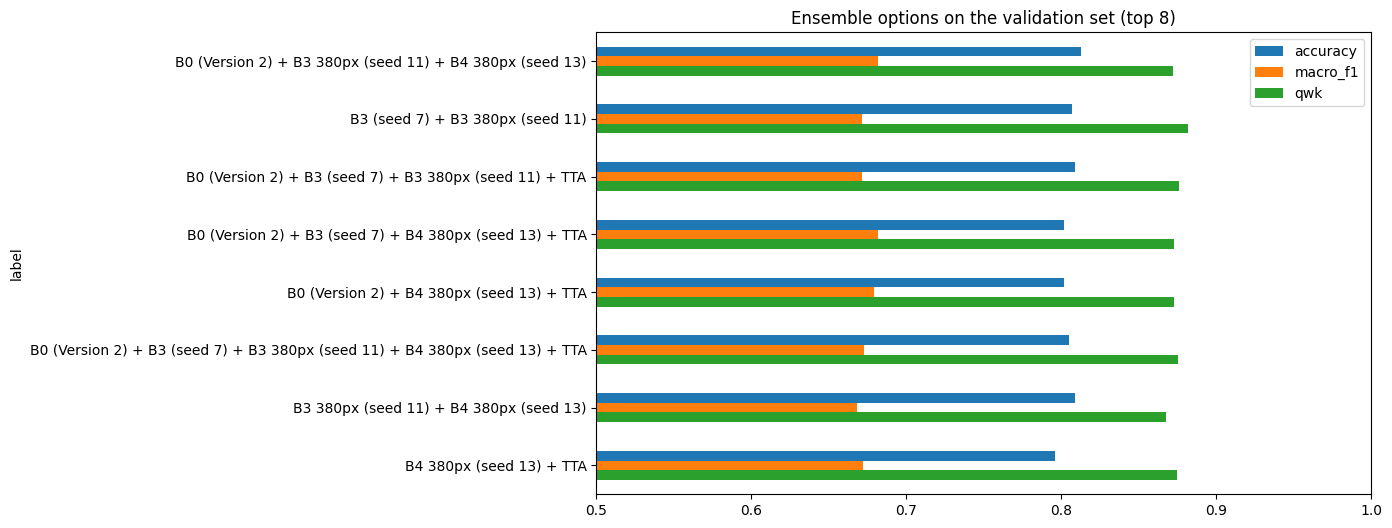

In [23]:
import itertools
USE_ENSEMBLE, ENSEMBLE_CHOICE = False, None
ens_models, ens_X = {"B0 (Version 2)": model}, {"B0 (Version 2)": X_all}
if RUN_ENSEMBLE:
    # 1. Load members saved by earlier runs (Version 3 ensemble) from the attached input
    root = os.environ.get("DR_DATA_ROOT", "/kaggle/input")
    for cfg_path in glob.glob(os.path.join(root, "**", "dr_config.json"), recursive=True):
        ens_cfg = json.load(open(cfg_path)).get("ensemble") or {}
        for mem in ens_cfg.get("members", []):
            if mem["file"] == "dr_model.keras" or mem["name"] in ens_models:
                continue
            path = os.path.join(os.path.dirname(cfg_path), mem["file"])
            if os.path.exists(path):
                ens_models[mem["name"]] = keras.models.load_model(path)
                ens_X[mem["name"]] = X_all
                print("Loaded earlier member:", mem["name"], "from", path)

    # 2. High-resolution copy of the dataset (same crop/pad/resize, then the selected preprocessing)
    t0 = time.time()
    X_hr = np.stack(Parallel(n_jobs=-1)(delayed(load_and_resize)(p, HIRES_SIZE) for p in df["path"]))
    if PREPROCESS_MODE != "raw":
        X_hr = np.stack([enhance(im, PREPROCESS_MODE) for im in X_hr])
    print(f"High-resolution set {X_hr.shape} built in {time.time() - t0:.0f}s | RAM GB: {ram_gb()}")

    # 3. Train the new members
    for bb, sd, size in ENSEMBLE_MEMBERS:
        name = f"{bb.replace('EfficientNet', '')} {size}px (seed {sd})"
        Xm = X_hr if size == HIRES_SIZE else X_all
        t0 = time.time()
        m_, _, _, _ = train_full(Xm, bb, BEST_LR, BEST_DROPOUT, BALANCE_METHOD, EPOCHS_HEAD, EPOCHS_FINE,
                                 verbose=2, seed=sd)
        ens_models[name], ens_X[name] = m_, Xm
        gc.collect()
        print(f"Trained {name} in {(time.time() - t0) / 60:.1f} min | RAM GB: {ram_gb()}")

    # 4. Probabilities of every member on validation and test, with and without TTA
    P = {}
    for name, m_ in ens_models.items():
        for tta in (False, True):
            P[(name, tta, "val")]  = predict_probs(m_, ens_X[name], val_idx, tta=tta)
            P[(name, tta, "test")] = predict_probs(m_, ens_X[name], test_idx, tta=tta)

    member_df = pd.DataFrame({name: metrics(val_true, P[(name, False, "val")].argmax(1)) for name in ens_models}).T.round(4)
    print("Each member on the validation set (no TTA):"); display(member_df)

    rows, names = [], list(ens_models)
    for k in range(1, len(names) + 1):
        for combo in itertools.combinations(names, k):
            for tta in (False, True):
                pv = np.mean([P[(n, tta, "val")] for n in combo], axis=0)
                m = metrics(val_true, pv.argmax(1))
                rows.append({"members": " + ".join(combo), "tta": tta, **m,
                             "mean_score": np.mean([m["accuracy"], m["macro_f1"], m["qwk"]])})
    ens_df = pd.DataFrame(rows).sort_values("mean_score", ascending=False).round(4).reset_index(drop=True)
    print("All combinations on the validation set (best first):"); display(ens_df.head(10))

    best = ens_df.iloc[0]
    single_best = float(opt_df["mean_score"].max())
    if best["mean_score"] > single_best:
        USE_ENSEMBLE = True
        ENSEMBLE_CHOICE = {"members": best["members"].split(" + "), "tta": bool(best["tta"])}
    print(f"Best ensemble option (validation mean score {best['mean_score']:.4f}) vs single model option "
          f"'{BEST_INFERENCE}' ({single_best:.4f}) -> using {'ENSEMBLE' if USE_ENSEMBLE else 'single model'}")

    top = ens_df.head(8).copy()
    top["label"] = top["members"] + np.where(top["tta"], " + TTA", "")
    top.set_index("label")[["accuracy", "macro_f1", "qwk"]].plot(kind="barh", figsize=(10, 6)).invert_yaxis()
    plt.xlim(0.5, 1); plt.title("Ensemble options on the validation set (top 8)")
    save_fig("14b_ensemble_selection.png"); plt.show()

def ensemble_probs(split):
    return np.mean([P[(n, ENSEMBLE_CHOICE["tta"], split)] for n in ENSEMBLE_CHOICE["members"]], axis=0)

## 13. Evaluation on the held-out test set
The test set was never used for training or for any selection above, so these numbers estimate real-world performance. The table also shows how much each inference step adds on the test set (for transparency only; the choice was made on validation).

Test set, by inference method:


,accuracy,macro_f1,qwk
argmax,0.7891,0.6324,0.8789
TTA + argmax,0.7964,0.6338,0.8777
TTA + thresholds,0.7600,0.5256,0.8923
Ensemble (best on validation),0.8036,0.6440,0.8766


Saved figure -> /kaggle/working/figures/14_inference_optimisation.png


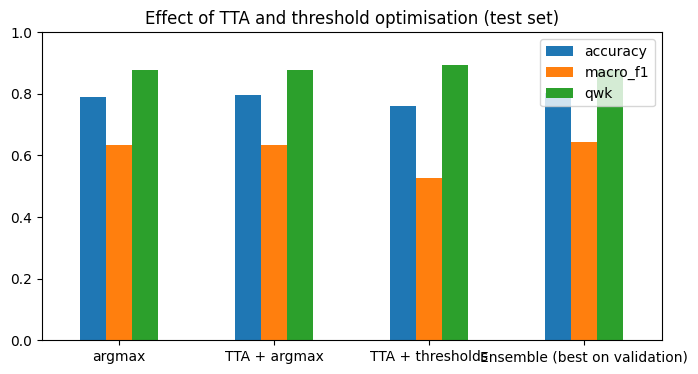

Final prediction method: ensemble of B0 (Version 2), B3 380px (seed 11), B4 380px (seed 13)
=== Multi-class (stage) results ===
  accuracy: 0.8036
  macro_f1: 0.6440
       qwk: 0.8766


,precision,recall,f1-score,support
No DR,0.9707,0.9779,0.9743,271.0000
Mild,0.4872,0.6786,0.5672,56.0000
Moderate,0.8217,0.7067,0.7599,150.0000
Severe,0.4000,0.4828,0.4375,29.0000
Proliferative DR,0.5429,0.4318,0.4810,44.0000
accuracy,0.8036,0.8036,0.8036,0.8036
macro avg,0.6445,0.6555,0.6440,550.0000
weighted avg,0.8165,0.8036,0.8066,550.0000


In [24]:
y_true = y_all[test_idx]
test_plain = predict_probs(model, X_all, test_idx, tta=False)
test_tta   = predict_probs(model, X_all, test_idx, tta=True)
step_df = pd.DataFrame({
    "argmax":           metrics(y_true, test_plain.argmax(1)),
    "TTA + argmax":     metrics(y_true, test_tta.argmax(1)),
    "TTA + thresholds": metrics(y_true, apply_thresholds(expected_grade(test_tta), THRESHOLDS)),
}).T.round(4)
if RUN_ENSEMBLE:
    ens_label = "Ensemble: " + " + ".join(ENSEMBLE_CHOICE["members"] if USE_ENSEMBLE else [ens_df.iloc[0]["members"]])
    ens_test = ensemble_probs("test") if USE_ENSEMBLE else np.mean(
        [P[(n, bool(ens_df.iloc[0]["tta"]), "test")] for n in ens_df.iloc[0]["members"].split(" + ")], axis=0)
    step_df.loc["Ensemble (best on validation)"] = pd.Series(metrics(y_true, ens_test.argmax(1))).round(4)
print("Test set, by inference method:"); display(step_df)
step_df[["accuracy", "macro_f1", "qwk"]].plot(kind="bar", figsize=(8, 4), rot=0); plt.ylim(0, 1)
plt.title("Effect of TTA and threshold optimisation (test set)")
save_fig("14_inference_optimisation.png"); plt.show()

if USE_ENSEMBLE:
    test_probs, DECISION = ensemble_probs("test"), "argmax"
else:
    test_probs = test_tta if USE_TTA else test_plain
y_pred = decide(test_probs)
print("Final prediction method:", ("ensemble of " + ", ".join(ENSEMBLE_CHOICE["members"]) +
      (" + TTA" if ENSEMBLE_CHOICE["tta"] else "")) if USE_ENSEMBLE else BEST_INFERENCE)
test_summary = metrics(y_true, y_pred)

print("=== Multi-class (stage) results ===")
for k, v in test_summary.items(): print(f"{k:>10}: {v:.4f}")
report = classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report).T.round(4)
display(report_df)
report_df.to_csv(os.path.join(OUT_DIR, "classification_report.csv"))

Saved figure -> /kaggle/working/figures/15_confusion_matrix.png


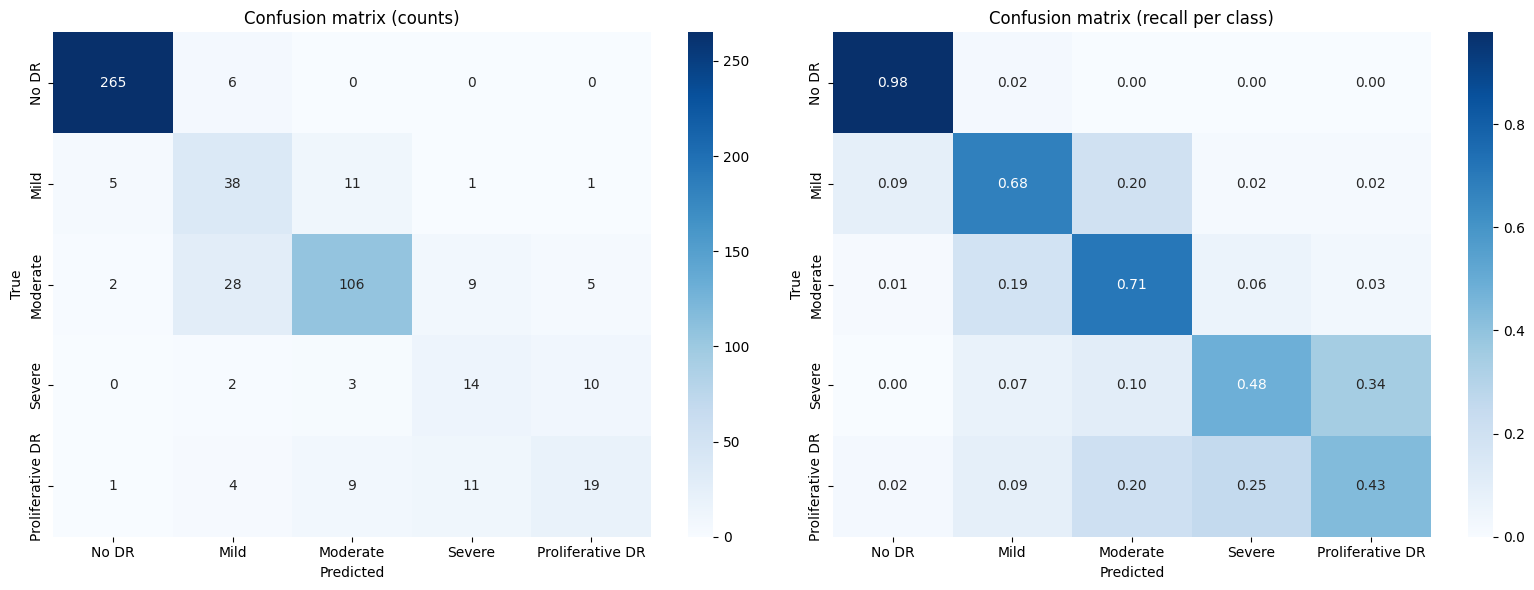

In [25]:
# ---------- Confusion matrices (counts and row-normalised) ----------
cm = confusion_matrix(y_true, y_pred, labels=range(NUM_CLASSES))
cm_norm = cm / cm.sum(1, keepdims=True)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1])
for ax, t in zip(axes, ["Confusion matrix (counts)", "Confusion matrix (recall per class)"]):
    ax.set_title(t); ax.set_xlabel("Predicted"); ax.set_ylabel("True")
plt.tight_layout(); save_fig("15_confusion_matrix.png"); plt.show()

Saved figure -> /kaggle/working/figures/16_per_class_prf.png


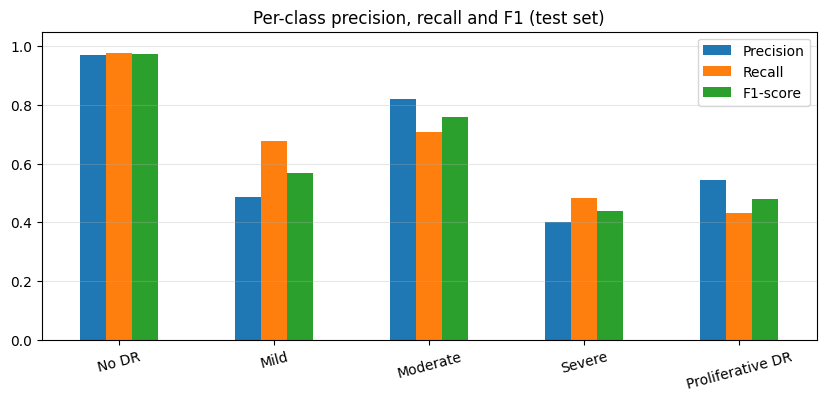

In [26]:
# ---------- Per-class precision / recall / F1 ----------
p, r, f, s = precision_recall_fscore_support(y_true, y_pred, labels=range(NUM_CLASSES), zero_division=0)
prf = pd.DataFrame({"Precision": p, "Recall": r, "F1-score": f}, index=CLASS_NAMES)
prf.plot(kind="bar", figsize=(10, 4), rot=15); plt.ylim(0, 1.05)
plt.title("Per-class precision, recall and F1 (test set)"); plt.grid(axis="y", alpha=0.3)
save_fig("16_per_class_prf.png"); plt.show()

=== DR vs No DR (screening) ===
              accuracy: 0.9782
  sensitivity (recall): 0.9785
           specificity: 0.9779
             precision: 0.9785
                    f1: 0.9785
               roc_auc: 0.9958


Saved figure -> /kaggle/working/figures/17_roc_binary.png


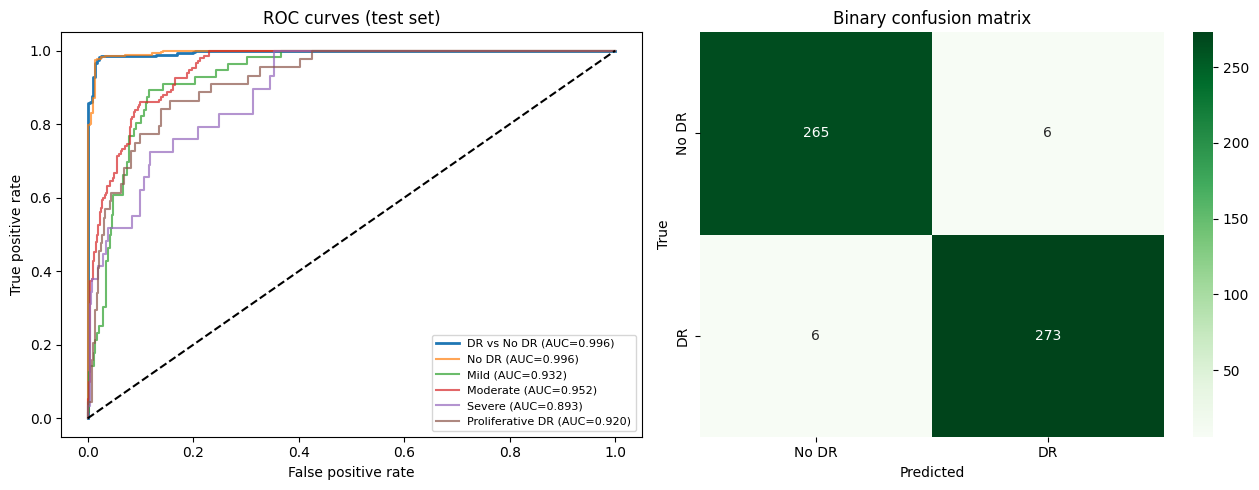

In [27]:
# ---------- Binary screening view: DR (stage 1-4) vs No DR (stage 0) ----------
yb_true = (y_true > 0).astype(int)
prob_dr = 1 - test_probs[:, 0]                     # P(any DR)
yb_pred = (prob_dr >= 0.5).astype(int)
tn, fp, fn, tp = confusion_matrix(yb_true, yb_pred, labels=[0, 1]).ravel()
binary = {"accuracy": (tp + tn) / (tp + tn + fp + fn),
          "sensitivity (recall)": tp / (tp + fn), "specificity": tn / (tn + fp),
          "precision": tp / max(tp + fp, 1), "f1": 2 * tp / max(2 * tp + fp + fn, 1),
          "roc_auc": roc_auc_score(yb_true, prob_dr)}
print("=== DR vs No DR (screening) ===")
for k, v in binary.items(): print(f"{k:>22}: {v:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fpr, tpr, _ = roc_curve(yb_true, prob_dr)
axes[0].plot(fpr, tpr, label=f"DR vs No DR (AUC={binary['roc_auc']:.3f})", lw=2)
for c in range(NUM_CLASSES):                        # one-vs-rest ROC for each stage
    if len(np.unique(y_true == c)) == 2:
        fc, tc, _ = roc_curve(y_true == c, test_probs[:, c])
        axes[0].plot(fc, tc, alpha=0.7, label=f"{CLASS_NAMES[c]} (AUC={roc_auc_score(y_true == c, test_probs[:, c]):.3f})")
axes[0].plot([0, 1], [0, 1], "k--"); axes[0].set_xlabel("False positive rate"); axes[0].set_ylabel("True positive rate")
axes[0].set_title("ROC curves (test set)"); axes[0].legend(fontsize=8)
sns.heatmap([[tn, fp], [fn, tp]], annot=True, fmt="d", cmap="Greens", ax=axes[1],
            xticklabels=["No DR", "DR"], yticklabels=["No DR", "DR"])
axes[1].set_title("Binary confusion matrix"); axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("True")
plt.tight_layout(); save_fig("17_roc_binary.png"); plt.show()

## 14. Error analysis
Distinguishes *near misses* (off by one stage — clinically less serious, and graders often disagree here too) from *severe errors* (≥ 2 stages apart).

,% of test images
Correct,80.4
Off by 1 stage,15.1
Off by >=2 stages,4.5


Most frequent confusions:


,True,Predicted,Count
6,Moderate,Mild,28
2,Mild,Moderate,11
15,Proliferative DR,Severe,11
11,Severe,Proliferative DR,10
7,Moderate,Severe,9
14,Proliferative DR,Moderate,9


Saved figure -> /kaggle/working/figures/18_misclassified.png


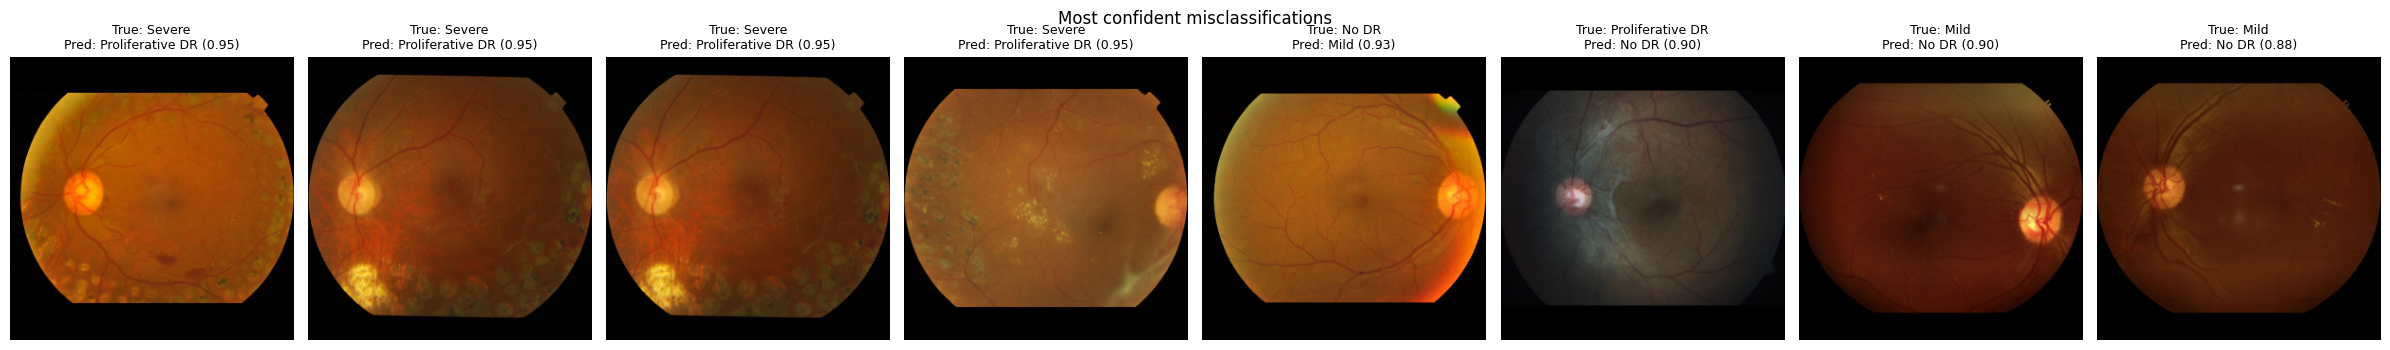

In [28]:
diff = np.abs(y_true - y_pred)
err = pd.Series({"Correct": (diff == 0).mean(), "Off by 1 stage": (diff == 1).mean(), "Off by >=2 stages": (diff >= 2).mean()})
display((err * 100).round(1).to_frame("% of test images"))

pairs = pd.DataFrame([(CLASS_NAMES[t], CLASS_NAMES[p_], cm[t, p_]) for t in range(NUM_CLASSES)
                      for p_ in range(NUM_CLASSES) if t != p_ and cm[t, p_] > 0],
                     columns=["True", "Predicted", "Count"]).sort_values("Count", ascending=False)
print("Most frequent confusions:"); display(pairs.head(6))

# Show the most confident mistakes
wrong = np.where(diff > 0)[0]
wrong = wrong[np.argsort(-test_probs[wrong].max(1))][:8]
if len(wrong):
    fig, axes = plt.subplots(1, len(wrong), figsize=(3 * len(wrong), 3.6))
    for ax, i in zip(np.atleast_1d(axes), wrong):
        ax.imshow(X_all[test_idx[i]]); ax.axis("off")
        ax.set_title(f"True: {CLASS_NAMES[y_true[i]]}\nPred: {CLASS_NAMES[y_pred[i]]} ({test_probs[i].max():.2f})", fontsize=9)
    plt.suptitle("Most confident misclassifications"); plt.tight_layout()
    save_fig("18_misclassified.png"); plt.show()

## 15. Explainability — Grad-CAM
Grad-CAM highlights the image regions that most influenced the prediction (gradients of the predicted class w.r.t. the last convolutional feature map). Heat on lesions (haemorrhages, exudates, new vessels) rather than the image border shows the model learned clinically meaningful features.

Saved figure -> /kaggle/working/figures/19_gradcam.png


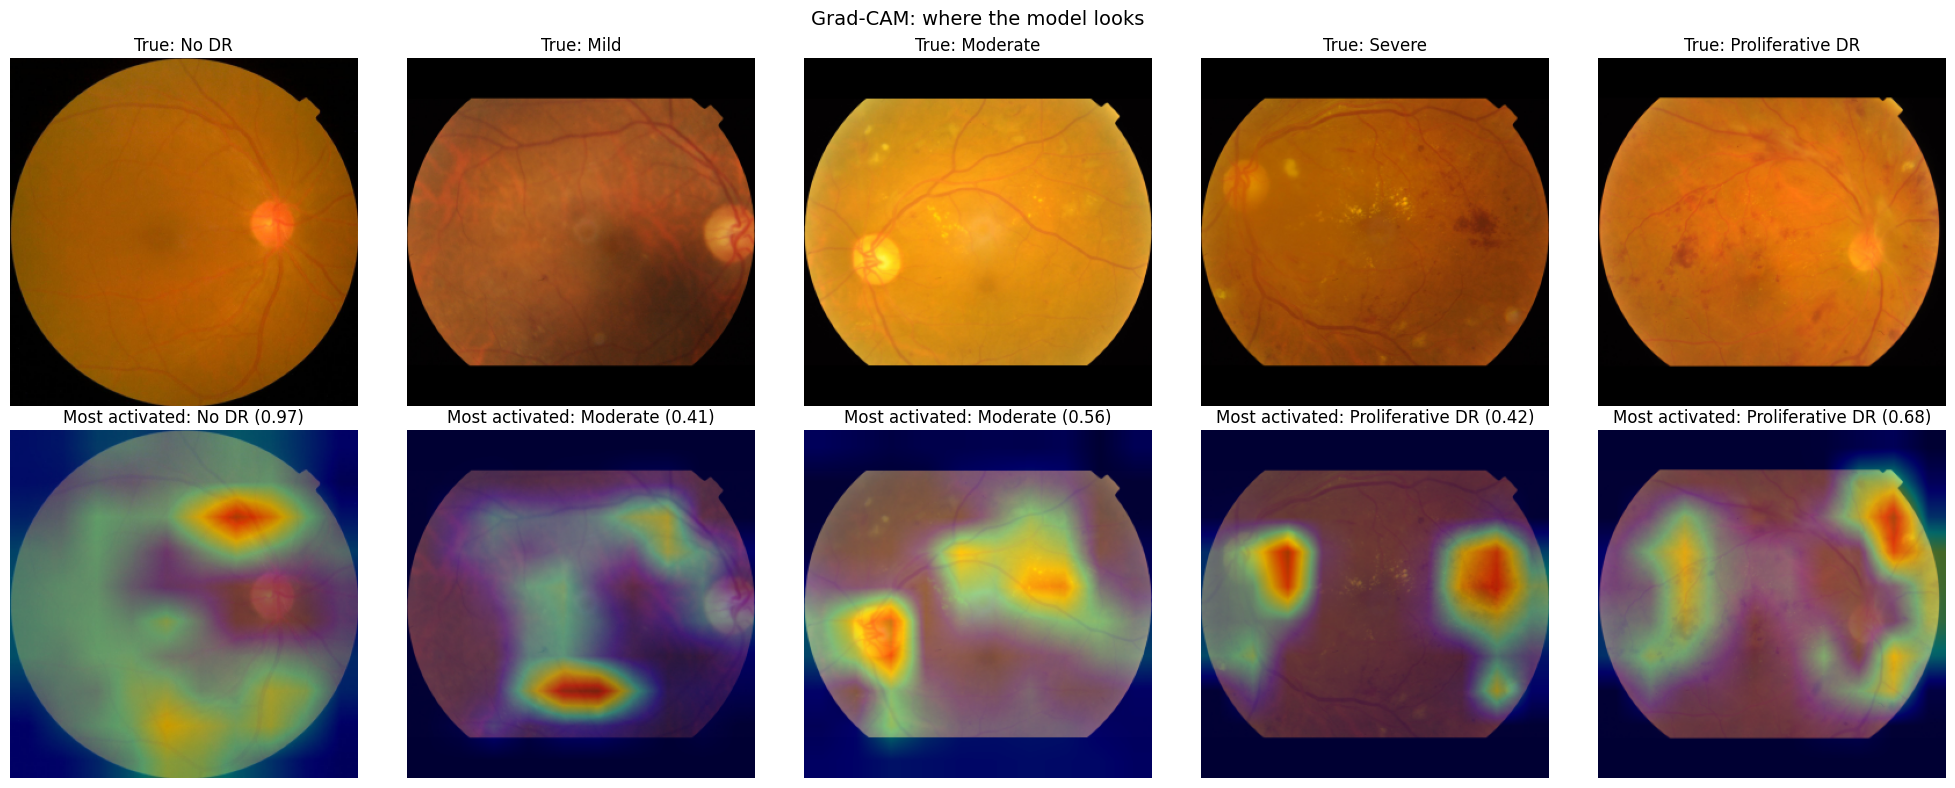

In [29]:
def grad_cam(model, img_uint8):
    # Run the model layer by layer so we can watch the backbone's output feature map
    base_layer = next(l for l in model.layers if isinstance(l, keras.Model))
    pos = model.layers.index(base_layer)
    x = tf.convert_to_tensor(img_uint8[None].astype("float32"))
    with tf.GradientTape() as tape:
        h = x
        for layer in model.layers[1:pos]:           # e.g. Rescaling
            h = layer(h)
        conv = base_layer(h, training=False)        # (1, h, w, C) last feature map
        tape.watch(conv)
        h = conv
        for layer in model.layers[pos + 1:]:        # GAP -> Dense ... -> softmax
            h = layer(h, training=False)
        cls = int(tf.argmax(h[0]))
        score = h[:, cls]
    grads = tape.gradient(score, conv)
    weights = tf.reduce_mean(grads, axis=(0, 1, 2))                  # importance of each channel
    cam = tf.nn.relu(tf.reduce_sum(conv[0] * weights, axis=-1)).numpy()
    cam = cv2.resize(cam / (cam.max() + 1e-8), (img_uint8.shape[1], img_uint8.shape[0]))
    heat = cv2.cvtColor(cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET), cv2.COLOR_BGR2RGB)
    overlay = cv2.addWeighted(img_uint8, 0.6, heat, 0.4, 0)
    return overlay, cls, h.numpy()[0]

fig, axes = plt.subplots(2, NUM_CLASSES, figsize=(4 * NUM_CLASSES, 8))
for c in range(NUM_CLASSES):
    cand = test_idx[y_all[test_idx] == c]
    if len(cand) == 0: continue
    img = X_all[cand[0]]
    overlay, pc, pr = grad_cam(model, img)
    axes[0, c].imshow(img); axes[0, c].set_title(f"True: {CLASS_NAMES[c]}")
    axes[1, c].imshow(overlay); axes[1, c].set_title(f"Most activated: {CLASS_NAMES[pc]} ({pr[pc]:.2f})")
    axes[0, c].axis("off"); axes[1, c].axis("off")
plt.suptitle("Grad-CAM: where the model looks", fontsize=14); plt.tight_layout()
save_fig("19_gradcam.png"); plt.show()

## 16. Save the model and results for the prototype app
Download these files from the **Output** panel (right side) → `/kaggle/working`:
- `dr_model.keras` — trained model
- `dr_config.json` — preprocessing mode, image size, class names, TTA / threshold settings, TF version (the app reads this)
- `results.json`, `classification_report.csv`, `training_log_*.csv`, `figures/*.png`

In [30]:
MODEL_PATH = os.path.join(OUT_DIR, "dr_model.keras")
model.save(MODEL_PATH)
ENSEMBLE_FILES = []
if USE_ENSEMBLE:
    for i, n in enumerate(ENSEMBLE_CHOICE["members"]):
        fname = "dr_model.keras" if n == "B0 (Version 2)" else f"dr_model_member{i}.keras"
        if fname != "dr_model.keras":
            ens_models[n].save(os.path.join(OUT_DIR, fname))
        ENSEMBLE_FILES.append({"name": n, "file": fname, "img_size": int(ens_X[n].shape[1])})

config = {"img_size": IMG_SIZE, "preprocess_mode": PREPROCESS_MODE, "backbone": BEST_BACKBONE,
          "class_names": CLASS_NAMES, "tta": bool(USE_TTA), "decision": DECISION,
          "thresholds": [float(t) for t in THRESHOLDS],
          "ensemble": ({"members": ENSEMBLE_FILES, "tta": ENSEMBLE_CHOICE["tta"]} if USE_ENSEMBLE else None),
          "tensorflow_version": tf.__version__, "keras_version": keras.__version__}
json.dump(config, open(os.path.join(OUT_DIR, "dr_config.json"), "w"), indent=2)

results = {"test_stage_metrics": test_summary, "test_binary_metrics": binary,
           "test_by_inference_method": step_df.to_dict(orient="index"),
           "validation_by_inference_method": opt_df.to_dict(orient="index"),
           "reused_model_from": PREV_DIR,
           "ensemble_validation": (ens_df.to_dict(orient="records") if RUN_ENSEMBLE else None),
           "ensemble_used": ENSEMBLE_CHOICE if USE_ENSEMBLE else None,
           "selected": {"preprocess": PREPROCESS_MODE, "backbone": BEST_BACKBONE, "lr": BEST_LR, "dropout": BEST_DROPOUT,
                        "balancing": BALANCE_METHOD, "img_size": IMG_SIZE, "inference": BEST_INFERENCE,
                        "thresholds": [float(t) for t in THRESHOLDS]},
           "epochs_trained": {"phase1": len(hist1.history["loss"]), "phase2": len(hist2.history["loss"])}}
json.dump(results, open(os.path.join(OUT_DIR, "results.json"), "w"), indent=2, default=float)
print(json.dumps(results, indent=2, default=float))
print("\nSaved:", MODEL_PATH, "| size:", round(os.path.getsize(MODEL_PATH) / 1e6, 1), "MB")

{
  "test_stage_metrics": {
    "accuracy": 0.8036363636363636,
    "macro_f1": 0.6439596348078103,
    "qwk": 0.8765585755063648
  },
  "test_binary_metrics": {
    "accuracy": 0.9781818181818182,
    "sensitivity (recall)": 0.978494623655914,
    "specificity": 0.977859778597786,
    "precision": 0.978494623655914,
    "f1": 0.978494623655914,
    "roc_auc": 0.995820603367324
  },
  "test_by_inference_method": {
    "argmax": {
      "accuracy": 0.7891,
      "macro_f1": 0.6324,
      "qwk": 0.8789
    },
    "TTA + argmax": {
      "accuracy": 0.7964,
      "macro_f1": 0.6338,
      "qwk": 0.8777
    },
    "TTA + thresholds": {
      "accuracy": 0.76,
      "macro_f1": 0.5256,
      "qwk": 0.8923
    },
    "Ensemble (best on validation)": {
      "accuracy": 0.8036,
      "macro_f1": 0.644,
      "qwk": 0.8766
    }
  },
  "validation_by_inference_method": {
    "argmax": {
      "accuracy": 0.7887,
      "macro_f1": 0.655,
      "qwk": 0.8657,
      "mean_score": 0.7698
    },
  

In [31]:
# ---------- Sanity check: reload the saved model and predict one image from disk ----------
reloaded = keras.models.load_model(MODEL_PATH)
p = df["path"].iloc[test_idx[0]]
img = preprocess_fundus(p, PREPROCESS_MODE)
batch = np.stack([img, img[:, ::-1], img[::-1], img[::-1, ::-1]]) if USE_TTA else img[None]
probs = reloaded.predict(batch.astype("float32"), verbose=0).mean(0)
print("Image:", os.path.basename(p), "| true:", CLASS_NAMES[y_all[test_idx[0]]])
for name, pr in zip(CLASS_NAMES, probs): print(f"  {name:<18} {pr:.3f}")
print("Prediction (Version 2 model alone):", CLASS_NAMES[int(probs.argmax())], "| DR present:", probs[1:].sum() >= 0.5)

2026-09-29 21:40:21.627284: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-29 21:40:21.763059: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


2026-09-29 21:40:22.560925: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-29 21:40:22.697355: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


Image: 89ee1fa16f90.png | true: Moderate
  No DR              0.018
  Mild               0.105
  Moderate           0.559
  Severe             0.191
  Proliferative DR   0.127
Prediction (Version 2 model alone): Moderate | DR present: True


In [ ]:
# ---------- Export demo images (unseen test images) + one zip with everything ----------
EX_DIR = os.path.join(OUT_DIR, "examples"); os.makedirs(EX_DIR, exist_ok=True)
for c in range(NUM_CLASSES):
    for i in test_idx[y_all[test_idx] == c][:2]:             # 2 test images per stage
        src = df["path"].iloc[i]
        shutil.copy(src, os.path.join(EX_DIR, f"stage{c}_{os.path.basename(src)}"))

for f in glob.glob(os.path.join(OUT_DIR, "*_best.keras")):   # duplicate of dr_model.keras, keep the zip small
    os.remove(f)
tmp_zip = shutil.make_archive("/tmp/dr_outputs", "zip", OUT_DIR)
shutil.move(tmp_zip, os.path.join(OUT_DIR, "dr_outputs.zip"))
print("Download dr_outputs.zip from the Output panel. Contents:")
print(sorted(os.listdir(OUT_DIR)))